# MDS gap-filling reconstruction and validation\n\n**Purpose.** Audit the project's existing Marginal Distribution Sampling (MDS) gap-filling implementation for FCH4 (`mds_fill_batch`/`run_mds`/`run_mds_capture` in `temp_gap_filling_pipeline.ipynb`) against the actual Reichstein et al. (2005)/REddyProc literature algorithm, diagnose why the current implementation's headline R2 is negative for all 3 towers (T2 -0.214, T4 -0.302, T9 -0.293, with the negativity concentrated in long-gap scenarios), and build + evaluate a literature-correct reimplementation via the exact same gap-CV harness already in use.\n\n**Scope.** All edits are confined to this notebook. `temp_gap_filling_pipeline.ipynb` is read-only reference material for every reused function and constant, and the eventual port-back destination -- not modified here.\n\n**Explicitly out of scope.** MDS's own `run_mds`/`mds_fill_batch` never touch FC (CO2 flux), management-event recency, GPP/Reco, or livestock density -- verified by tracing `run_mds`'s body in the source notebook. This notebook's data setup is therefore much thinner than the source notebook's full RFm pipeline: no FCO2 reconstruction, no management features, no GPP/Reco partitioning, no livestock joins. `d_all` here is just the external-sourced (`df_ext`) base, since MDS only ever reads FCH4 (target), FCH4_SSITC_TEST (QC flag), and the SW/TA/VPD driver columns.\n

## 0. Setup\n

In [1]:
from pathlib import Path
import functools
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

TIMING_STATS = defaultdict(lambda: {"calls": 0, "total_s": 0.0})


def timeit(func):
    """Accumulates call count + total wall time per function into TIMING_STATS (no per-call
    print). See print_timing_summary() for the report."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.perf_counter()
        result = func(*args, **kwargs)
        dt = time.perf_counter() - t0
        stats = TIMING_STATS[func.__name__]
        stats["calls"] += 1
        stats["total_s"] += dt
        return result
    return wrapper


def print_timing_summary(top_n=None):
    rows = sorted(TIMING_STATS.items(), key=lambda kv: -kv[1]["total_s"])
    if top_n:
        rows = rows[:top_n]
    print(f'{"function":32s} {"calls":>8s} {"total_s":>10s} {"avg_ms":>10s}')
    for name, s in rows:
        avg_ms = 1000 * s["total_s"] / max(s["calls"], 1)
        print(f'{name:32s} {s["calls"]:8d} {s["total_s"]:10.2f} {avg_ms:10.2f}')


HOURLY = Path("../../data/Hourly")

TOWERS = [2, 4, 9]
C4 = "Catchment 4 After  2013/08/13"           # Tower 4's catchment column suffix (note double space)
CAT = {2: "Catchment 2", 4: C4, 9: "Catchment 9"}

PLAUS_LOW, PLAUS_HIGH = -500, 3000   # nmol m-2 s-1 plausibility bound for FCH4 (D-13)
DOMAIN = {2: ("2017-10-01", "2019-06-30"), 4: ("2017-10-01", "2023-12-31"), 9: ("2020-02-01", "2023-12-31")}

print("Setup complete.")


Setup complete.


## 1. Minimal data setup\n\nLoads `consolidated_hourly.csv` and rebuilds just the external-sourced (D-35) SW/TA/WS swap (`df_ext`). Skips `met_filled`/`fco2_gapfilled`/`mgmt`/`gpp_reco` entirely -- MDS never reads FC/management/GPP-Reco/livestock columns (verified by tracing `run_mds` in the source notebook), so `d_all = df_ext` is sufficient here.\n\n**Important, verified this session:** MDS's own SW/TA/VPD driver columns (as read by `run_mds`/`mds_fill_batch`) are the *raw* (site-swapped but not gap-filled) columns in `df_ext` -- not the pipeline's separately-built, differently-named `__f` gap-filled variants. The coverage check below surfaces how much raw missingness (especially VPD) MDS's own drivers actually carry.\n

In [2]:
raw = pd.read_csv(HOURLY / "consolidated_hourly.csv", low_memory=False)
raw["Datetime"] = pd.to_datetime(raw["Datetime"], format="mixed")
raw = raw.set_index("Datetime")
print(f"raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} cols, span {raw.index.min()} -> {raw.index.max()}")

SITE_SW = "Solar Radiation (W/m2) [Site]"
SITE_TA = "Air Temperature (oC) [Site]"
SITE_WS = "Wind Speed (km/h) [Site]"

df_ext = raw.copy()
for t in TOWERS:
    for ec_col, site_col, conv in [(f"SWIN_1_1_1 [Tower {t}]", SITE_SW, 1.0),
                                    (f"TA_0_0_1 [Tower {t}]", SITE_TA, 1.0),
                                    (f"WS_0_0_1 [Tower {t}]", SITE_WS, 1.0 / 3.6)]:   # km/h -> m/s
        df_ext[ec_col] = pd.to_numeric(raw[site_col], errors="coerce") * conv

d_all = df_ext   # MDS never reads FC/management/GPP-Reco/livestock columns (verified against run_mds)


@timeit
def dom_mask(idx, t):
    a, b = DOMAIN[t]
    return (idx >= pd.Timestamp(a)) & (idx <= pd.Timestamp(b))


def cfg(t):
    cat = CAT[t]
    return dict(t=t, cat=cat, tgt=f"FCH4_1_1_1 [Tower {t}]", ssitc=f"FCH4_SSITC_TEST_1_1_1 [Tower {t}]",
                sw=f"SWIN_1_1_1 [Tower {t}]", ta=f"TA_0_0_1 [Tower {t}]", vpd=f"VPD_0_0_1 [Tower {t}]")


def qc_target(t):
    """QC'd FCH4 series for tower t: SSITC in {0,1} and within the plausibility bound (D-13)."""
    c = cfg(t)
    s = d_all[c["tgt"]].astype(float).copy()
    s[~d_all[c["ssitc"]].isin([0, 1])] = np.nan
    s[s.notna() & ~s.between(PLAUS_LOW, PLAUS_HIGH, inclusive="both")] = np.nan
    return s


print("\nPer-tower raw driver coverage (site-swapped SW/TA, raw VPD) and QC'd target coverage, within each tower's DOMAIN:")
for t in TOWERS:
    c = cfg(t)
    dm = dom_mask(d_all.index, t)
    sub = d_all.loc[dm]
    tgt_valid = qc_target(t).loc[dm].notna().mean()
    print(f"  Tower {t}: FCH4(QC'd) {100*tgt_valid:5.1f}%  |  SW {100*sub[c['sw']].notna().mean():5.1f}%  "
          f"TA {100*sub[c['ta']].notna().mean():5.1f}%  VPD {100*sub[c['vpd']].notna().mean():5.1f}%  "
          f"(domain {DOMAIN[t][0]} -> {DOMAIN[t][1]}, n={dm.sum():,})")


raw shape: 70,153 rows x 449 cols, span 2017-01-01 00:00:00 -> 2025-01-02 00:00:00

Per-tower raw driver coverage (site-swapped SW/TA, raw VPD) and QC'd target coverage, within each tower's DOMAIN:
  Tower 2: FCH4(QC'd)  32.0%  |  SW 100.0%  TA 100.0%  VPD  71.9%  (domain 2017-10-01 -> 2019-06-30, n=15,289)
  Tower 4: FCH4(QC'd)  35.5%  |  SW  98.7%  TA  98.7%  VPD  85.8%  (domain 2017-10-01 -> 2023-12-31, n=54,769)
  Tower 9: FCH4(QC'd)  32.7%  |  SW  97.9%  TA  97.9%  VPD  61.4%  (domain 2020-02-01 -> 2023-12-31, n=34,297)


## 2. Shared gap-CV harness (fixed invariant)\n\nCopied verbatim from `temp_gap_filling_pipeline.ipynb`. This cell must not be edited beyond this point in the notebook -- any OLD-vs-NEW difference in results must come from `mds_fill_batch` itself, never from a harness change. `SCENARIOS`/`N_REPS`/`seed=0` match the source notebook exactly, so the OLD-implementation reproduction in section 3 is a fair, apples-to-apples check.\n

In [3]:
MASK_FRAC = 0.25
SCENARIOS = {"vs": 1, "s": 4, "m": 32, "l": 288, "m1": "mixed"}
N_REPS = 2   # matches temp_gap_filling_pipeline.ipynb's F-09a scope


@timeit
def insert_calendar_gaps(df_qc, target, domain_mask, gap_hours, n_reps=N_REPS, seed=0):
    """Randomly place n_reps independent sets of non-overlapping calendar-shaped gaps within the
    domain, each covering ~MASK_FRAC of the domain's valid target points."""
    dom_ts = df_qc.index[domain_mask]; valid = df_qc.loc[domain_mask, target].notna().values
    n = len(dom_ts); target_n = max(1, int(valid.sum() * MASK_FRAC)); rb = np.random.default_rng(seed); reps = []
    for _ in range(n_reps):
        rng = np.random.default_rng(int(rb.integers(0, 2**31))); occ = np.zeros(n, bool); m = 0
        for sp in rng.permutation(n):
            if m >= target_n:
                break
            gh = int(rng.choice([1, 4, 32, 288])) if gap_hours == "mixed" else gap_hours
            ep = min(int(sp) + gh, n)
            if occ[sp:ep].any():
                continue
            occ[sp:ep] = True; m += int(valid[sp:ep].sum())
        reps.append(dom_ts[occ & valid])
    return reps


@timeit
def mets(y, p):
    y = np.asarray(y, float); p = np.asarray(p, float)
    r2 = r2_score(y, p) if np.var(y) > 0 else np.nan
    return r2, float(np.sqrt(np.mean((p - y) ** 2))), float(np.mean(np.abs(p - y))), float(np.mean(p - y))


@timeit
def med_metrics(rows):
    if not rows:
        return {k: np.nan for k in ["R2", "RMSE", "MAE", "MBE"]}
    a = np.array(rows, float)
    return {"R2": np.nanmedian(a[:, 0]), "RMSE": np.median(a[:, 1]),
            "MAE": np.median(a[:, 2]), "MBE": np.median(a[:, 3])}


print("Harness ready:", list(SCENARIOS.items()), f"N_REPS={N_REPS}")


Harness ready: [('vs', 1), ('s', 4), ('m', 32), ('l', 288), ('m1', 'mixed')] N_REPS=2


## 3. OLD implementation -- exact reproduction\n\n`mds_fill_batch_old` is a byte-for-byte copy of the current production `mds_fill_batch` (verified directly against `temp_gap_filling_pipeline.ipynb`'s source this session) -- kept only for this audit's side-by-side comparison, NOT the version to port back.\n\n`run_mds` is copied verbatim except for one small, deliberate generalization: a `fill_fn` parameter (defaulting to `mds_fill_batch_old`) so the exact same harness call can later drive `mds_fill_batch_new` (section 5) without duplicating the driver-column/QC logic in two places. `data` similarly overrides `d_all` (used only by the VPD ablation in section 7). This is flagged explicitly as a labeled deviation from strict verbatim-ness, not a hidden change.\n

In [4]:
@timeit
def mds_fill_batch_old(df_obs, target, sw_col, ta_col, gap_ts, vpd_col=None):
    """Current production mds_fill_batch (temp_gap_filling_pipeline.ipynb), copied verbatim for
    this audit's side-by-side comparison -- NOT the version to port back."""
    SW_TOL, TA_TOL, VPD_TOL = 50.0, 2.5, 5.0
    WINDOWS = [pd.Timedelta(days=d) for d in [7, 14, 28, 91]]
    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); adoy = av.index.dayofyear.to_numpy(); ats = av.index.to_numpy()
    asw = av[sw_col].values.astype(float); ata = av[ta_col].values.astype(float)
    avpd = av[vpd_col].values.astype(float) if vpd_col is not None else None
    gi = pd.DatetimeIndex(gap_ts)
    gsw = df_obs.reindex(gi)[sw_col].values.astype(float); gta = df_obs.reindex(gi)[ta_col].values.astype(float)
    gvpd = df_obs.reindex(gi)[vpd_col].values.astype(float) if vpd_col is not None else None
    preds = {}
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour; doy = t.dayofyear; sv = gsw[i]; tv = gta[i]
        vv = gvpd[i] if gvpd is not None else np.nan
        day = (not np.isnan(sv)) and sv > 10.0; filled = False
        for wd in WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w) & (np.abs(ahr - hr) <= 1)
            if not np.isnan(tv):
                m &= (np.abs(ata - tv) <= TA_TOL) | np.isnan(ata)
            if avpd is not None and not np.isnan(vv):
                m &= (np.abs(avpd - vv) <= VPD_TOL) | np.isnan(avpd)
            if day and not np.isnan(sv):
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; break
        if not filled:
            sh = np.abs(ahr - hr) <= 1
            dd = np.minimum(np.abs(adoy - doy), 365 - np.abs(adoy - doy))
            c = ay[sh & (dd <= 7)]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c))
    return preds


@timeit
def run_mds(t, fill_fn=None, data=None):
    """Gap-CV driver for tower t. fill_fn defaults to mds_fill_batch_old; pass mds_fill_batch_new
    (section 5) to drive the identical harness through the literature-corrected implementation.
    `data` overrides d_all (used by the VPD ablation, section 7)."""
    fill_fn = fill_fn or mds_fill_batch_old
    d = (data if data is not None else d_all).copy(); c = cfg(t); tgt = c["tgt"]
    d.loc[~d[c["ssitc"]].isin([0, 1]), tgt] = np.nan
    d.loc[d[tgt].notna() & ~d[tgt].between(PLAUS_LOW, PLAUS_HIGH, inclusive="both"), tgt] = np.nan
    dm = dom_mask(d.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(d, tgt, dm, gh):
            if len(gt) < 5:
                continue
            sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
            p = fill_fn(d, tgt, c["sw"], c["ta"], list(gt), vpd_col=c["vpd"]); d.loc[gt, tgt] = sav
            ts_ = [x for x in gt if x in p]
            if len(ts_) >= 5:
                rr.append(mets(sav.loc[ts_].values, np.array([p[x] for x in ts_])))
        out[sc] = med_metrics(rr)
    return out


@timeit
def run_mds_gapsets(t):
    """Returns the exact per-(scenario, rep) gap-timestamp sets insert_calendar_gaps produces for
    tower t -- deterministic (fixed seed=0) given the same QC'd target/domain, so this reproduces
    exactly what run_mds's inner loop used, letting diagnostics run on identical query points."""
    tgt = cfg(t)["tgt"]
    d = d_all.copy(); d[tgt] = qc_target(t)
    dm = dom_mask(d.index, t); gap_sets = {}
    for sc, gh in SCENARIOS.items():
        for rep_i, gt in enumerate(insert_calendar_gaps(d, tgt, dm, gh)):
            if len(gt) >= 5:
                gap_sets[(t, sc, rep_i)] = list(gt)
    return gap_sets


In [5]:
GAP_SETS_OLD = {}
for t in TOWERS:
    GAP_SETS_OLD.update(run_mds_gapsets(t))
print(f"Captured {len(GAP_SETS_OLD)} (tower, scenario, rep) gap-timestamp sets.")

RESULTS_OLD = {t: run_mds(t, fill_fn=mds_fill_batch_old) for t in TOWERS}

rows = []
for t in TOWERS:
    for sc in SCENARIOS:
        rows.append({"tower": t, "scenario": sc, **RESULTS_OLD[t][sc]})
old_scenario_table = pd.DataFrame(rows)
old_headline = {t: np.nanmedian([RESULTS_OLD[t][sc]["R2"] for sc in SCENARIOS]) for t in TOWERS}

print("\nPer-scenario R2 (OLD implementation):")
print(old_scenario_table.pivot(index="scenario", columns="tower", values="R2").loc[list(SCENARIOS)].round(3))

print("\nHeadline (median-of-scenario-medians) R2, OLD implementation vs. recorded baseline:")
recorded_baseline = {2: -0.214, 4: -0.302, 9: -0.293}
for t in TOWERS:
    print(f"  Tower {t}: reproduced={old_headline[t]:.3f}  |  recorded={recorded_baseline[t]:.3f}")


Captured 30 (tower, scenario, rep) gap-timestamp sets.



Per-scenario R2 (OLD implementation):
tower         2      4      9
scenario                     
vs       -0.039 -0.253 -0.209
s        -0.214 -0.125 -0.293
m        -0.182 -0.302 -0.159
l        -2.457 -0.420 -0.502
m1       -1.413 -0.527 -0.339

Headline (median-of-scenario-medians) R2, OLD implementation vs. recorded baseline:
  Tower 2: reproduced=-0.214  |  recorded=-0.214
  Tower 4: reproduced=-0.302  |  recorded=-0.302
  Tower 9: reproduced=-0.293  |  recorded=-0.293


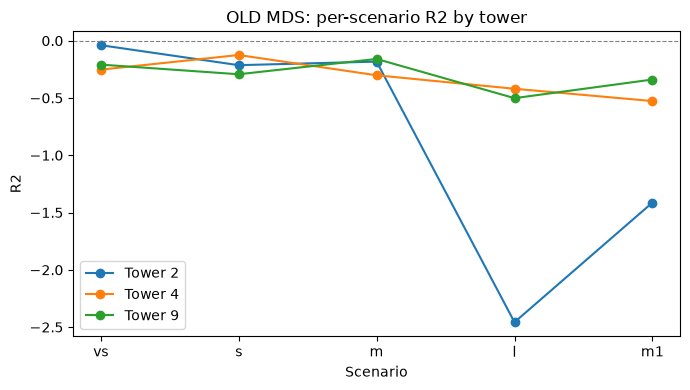

In [6]:
order = ["vs", "s", "m", "l", "m1"]
fig, ax = plt.subplots(figsize=(7, 4))
for t in TOWERS:
    vals = [RESULTS_OLD[t][sc]["R2"] for sc in order]
    ax.plot(order, vals, marker="o", label=f"Tower {t}")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("Scenario"); ax.set_ylabel("R2"); ax.set_title("OLD MDS: per-scenario R2 by tower")
ax.legend(); plt.tight_layout(); plt.show()


## 4. Diagnostics on the OLD implementation\n\nReproduced above: Tower 2's "l" (288h) scenario alone hits R2=-2.457, while Tower 4/9's "l" scenarios are far milder (-0.42/-0.50). This section builds real, data-driven diagnostics -- not just theory -- to characterize *why*: `mds_fill_batch_diag` is a near-copy of `mds_fill_batch_old` that additionally records, per gap point, which window/path matched and the candidate-pool size at the winning branch. It is run on the *exact* `GAP_SETS_OLD` query points (not fresh gaps) so the diagnostics are faithful to the R2 numbers already computed above, and its `preds` output is asserted identical to `mds_fill_batch_old`'s to prove the instrumentation adds visibility without changing fill behaviour.\n\nPlotting/summary functions are written generically (taking any diagnostics dataframe) so section 6 can reuse them unchanged for the NEW implementation.\n

In [7]:
@timeit
def mds_fill_batch_diag(df_obs, target, sw_col, ta_col, gap_ts, vpd_col=None):
    """Instrumented copy of mds_fill_batch_old: identical fill logic, additionally records which
    window/path matched and the candidate-pool size at the winning branch. Returns (preds, diag_df);
    preds must be identical to mds_fill_batch_old's output on the same inputs (asserted below)."""
    SW_TOL, TA_TOL, VPD_TOL = 50.0, 2.5, 5.0
    WINDOWS = [(f"win_{d}d", pd.Timedelta(days=d)) for d in [7, 14, 28, 91]]
    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); adoy = av.index.dayofyear.to_numpy(); ats = av.index.to_numpy()
    asw = av[sw_col].values.astype(float); ata = av[ta_col].values.astype(float)
    avpd = av[vpd_col].values.astype(float) if vpd_col is not None else None
    gi = pd.DatetimeIndex(gap_ts)
    gsw = df_obs.reindex(gi)[sw_col].values.astype(float); gta = df_obs.reindex(gi)[ta_col].values.astype(float)
    gvpd = df_obs.reindex(gi)[vpd_col].values.astype(float) if vpd_col is not None else None
    preds = {}; diag = []
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour; doy = t.dayofyear; sv = gsw[i]; tv = gta[i]
        vv = gvpd[i] if gvpd is not None else np.nan
        day = (not np.isnan(sv)) and sv > 10.0; filled = False; path = "unfilled"; n_cand = 0
        for wname, wd in WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w) & (np.abs(ahr - hr) <= 1)
            if not np.isnan(tv):
                m &= (np.abs(ata - tv) <= TA_TOL) | np.isnan(ata)
            if avpd is not None and not np.isnan(vv):
                m &= (np.abs(avpd - vv) <= VPD_TOL) | np.isnan(avpd)
            if day and not np.isnan(sv):
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break
        if not filled:
            sh = np.abs(ahr - hr) <= 1
            dd = np.minimum(np.abs(adoy - doy), 365 - np.abs(adoy - doy))
            c = ay[sh & (dd <= 7)]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); path = "fallback_doy7"; n_cand = len(c)
        diag.append({"gap_ts": t, "path": path, "n_candidates": n_cand, "hour": hr, "is_day": day})
    return preds, pd.DataFrame(diag).set_index("gap_ts")


def run_diag(t, fill_fn_clean, fill_fn_diag, gap_sets=None):
    """Re-drives every (scenario, rep) gap set for tower t through both fill_fn_clean and
    fill_fn_diag on identical masked data, asserts their preds agree, and returns the combined
    per-gap-point diagnostics dataframe (with scenario/rep/tower/edge-distance columns added)."""
    gap_sets = gap_sets or GAP_SETS_OLD
    c = cfg(t); tgt = c["tgt"]; frames = []
    dom_start, dom_end = pd.Timestamp(DOMAIN[t][0]), pd.Timestamp(DOMAIN[t][1])
    for (tt, sc, rep), gt in gap_sets.items():
        if tt != t:
            continue
        d = d_all.copy(); d[tgt] = qc_target(t)
        d.loc[gt, tgt] = np.nan
        preds_clean = fill_fn_clean(d, tgt, c["sw"], c["ta"], gt, vpd_col=c["vpd"])
        preds_diag, diag = fill_fn_diag(d, tgt, c["sw"], c["ta"], gt, vpd_col=c["vpd"])
        assert set(preds_clean) == set(preds_diag), f"key mismatch T{t} {sc} rep{rep}"
        assert all(abs(preds_clean[k] - preds_diag[k]) < 1e-9 for k in preds_clean), \
            f"prediction mismatch T{t} {sc} rep{rep} -- diagnostic variant diverged from clean implementation"
        diag = diag.copy()
        diag["scenario"] = sc; diag["rep"] = rep; diag["tower"] = t
        diag["days_to_start"] = (diag.index - dom_start).total_seconds() / 86400
        diag["days_to_end"] = (dom_end - diag.index).total_seconds() / 86400
        diag["edge_dist"] = diag[["days_to_start", "days_to_end"]].min(axis=1)
        frames.append(diag)
    return pd.concat(frames)


DIAG_OLD = {t: run_diag(t, mds_fill_batch_old, mds_fill_batch_diag) for t in TOWERS}
diag_old_all = pd.concat(DIAG_OLD.values())
print("Diagnostics OK -- mds_fill_batch_diag reproduces mds_fill_batch_old's predictions exactly.")
print(f"Total diagnosed gap points: {len(diag_old_all):,}")


Diagnostics OK -- mds_fill_batch_diag reproduces mds_fill_batch_old's predictions exactly.
Total diagnosed gap points: 89,280


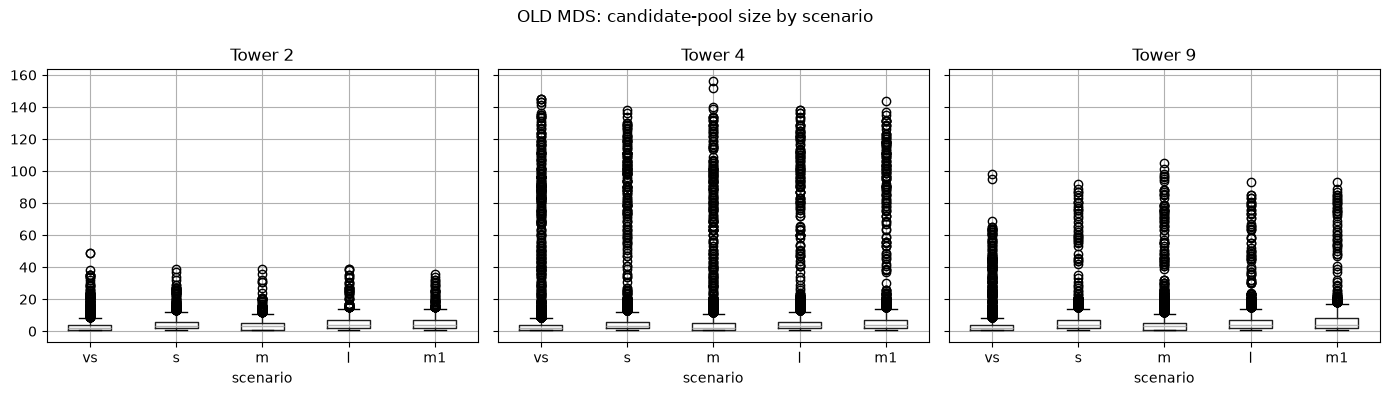

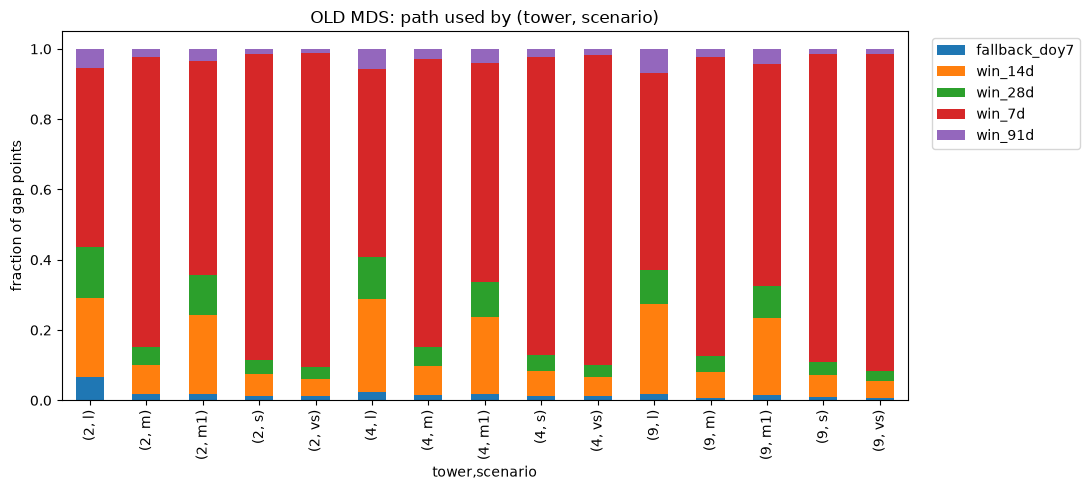

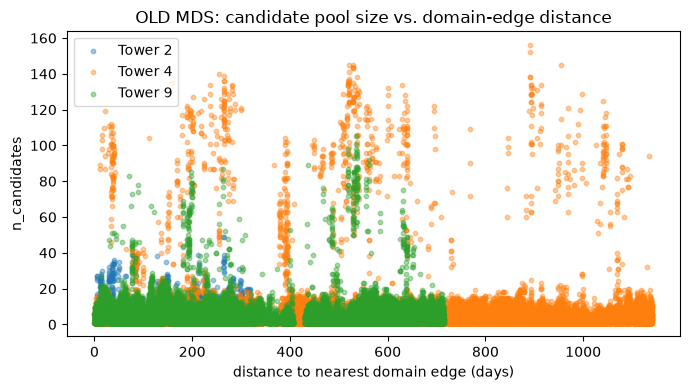

                median_n_candidates  pct_unfilled  pct_fallback
tower scenario                                                 
2     l                         2.0           0.0          6.55
      m                         3.0           0.0          1.75
      m1                        3.0           0.0          1.87
      s                         4.0           0.0          1.31
      vs                        4.0           0.0          1.15
4     l                         2.0           0.0          2.48
      m                         3.0           0.0          1.55
      m1                        2.0           0.0          1.69
      s                         3.0           0.0          1.35
      vs                        4.0           0.0          1.32
9     l                         2.0           0.0          1.92
      m                         4.0           0.0          0.69
      m1                        3.0           0.0          1.53
      s                         4.0     

In [8]:
def plot_candidate_pool(diag_all, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, t in zip(axes, TOWERS):
        sub = diag_all[diag_all["tower"] == t]
        sub.boxplot(column="n_candidates", by="scenario", ax=ax, positions=range(len(order)))
        ax.set_xticklabels(order); ax.set_title(f"Tower {t}"); ax.set_xlabel("scenario")
    fig.suptitle(title); plt.tight_layout(); plt.show()


def plot_path_stacked(diag_all, title):
    counts = diag_all.groupby(["tower", "scenario", "path"]).size().unstack(fill_value=0)
    frac = counts.div(counts.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(11, 5))
    frac.plot(kind="bar", stacked=True, ax=ax)
    ax.set_ylabel("fraction of gap points"); ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()


def plot_edge_scatter(diag_all, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    for t in TOWERS:
        sub = diag_all[diag_all["tower"] == t]
        ax.scatter(sub["edge_dist"], sub["n_candidates"], s=10, alpha=0.4, label=f"Tower {t}")
    ax.set_xlabel("distance to nearest domain edge (days)"); ax.set_ylabel("n_candidates")
    ax.set_title(title); ax.legend(); plt.tight_layout(); plt.show()


def diag_summary_table(diag_all):
    return diag_all.groupby(["tower", "scenario"]).agg(
        median_n_candidates=("n_candidates", "median"),
        pct_unfilled=("path", lambda s: 100 * (s == "unfilled").mean()),
        pct_fallback=("path", lambda s: 100 * (s.str.startswith("fallback")).mean()),
    ).round(2)


plot_candidate_pool(diag_old_all, "OLD MDS: candidate-pool size by scenario")
plot_path_stacked(diag_old_all, "OLD MDS: path used by (tower, scenario)")
plot_edge_scatter(diag_old_all, "OLD MDS: candidate pool size vs. domain-edge distance")
print(diag_summary_table(diag_old_all))


**Diagnostic finding (OLD implementation):** candidate pools are chronically tiny -- median 2-4 real observations per gap point, across *every* scenario and tower, not just long gaps. This is consistent with the literature-verification finding that the current code applies the hour-of-day +/-1h restriction uniformly, in every window/case: at any window size, only ~2 of 24 hours are eligible, so widening the calendar window (7->14->28->91 days) barely grows the pool once the hour restriction is already the binding constraint. Tower 2's "l" scenario has both the smallest median pool (2) and the highest fallback-path usage (6.55%, the highest of any tower/scenario combination) -- consistent with *both* mechanisms (hour-restriction-driven starvation everywhere, compounded by Tower 2's short ~21-month domain specifically for long gaps).\n\n## 5. NEW literature-correct MDS (3-case hierarchy)\n\nVerified this session via direct inspection of REddyProc's own R source (`EddyGapfilling.R`) and MPI-BGC's official gap-filling documentation. The real algorithm is a hierarchy, not a single unified loop:\n\n- **Case 1** (SW+TA+VPD look-up table): windows +/-7d, then +/-14d only. **No hour-of-day restriction** -- all records in the day-window are eligible, constrained only by the meteorological tolerances (+/-50 W/m2, +/-2.5 degC, +/-5 hPa, unchanged). Requires all three drivers non-NaN at the query point to attempt.\n- **Case 2** (SW-only look-up table): windows +/-7d, then +/-14,21,...,70d (step 7). Still no hour-of-day restriction. **Judgment call:** kept day-gated (`SW>10`) consistent with the existing codebase convention, since Rg carries no discriminating signal at night anyway.\n- **Case 3** (mean diurnal course, meteo-free): the *only* case with an hour-of-day (+/-1h) restriction. Windows expand 0, 1, 2 days, then step-7 to +/-210 days. **Judgment call:** this exact cadence beyond 0/1/2 days is the one detail not independently confirmed against the primary 2005 paper (only against REddyProc's current R source/docs) -- flagged as revisable; section 6's diagnostics show how often this case is even reached, which bounds how much the exact cadence could matter.\n- **No 4th fallback.** If Case 3 exhausts +/-210d with nothing, the point stays unfilled -- a real behaviour change from the old code's guaranteed-fill fallback, tracked via the fill-rate comparison in section 6.\n\nThis also structurally fixes the VPD-plumbing issue found in section 1: Case 1 requires all three drivers non-NaN to even attempt; if VPD is NaN at the query point, the point now falls through to Case 2 (a real rung with its own criteria) rather than silently attempting Case-1-style TA/SW matching with the VPD constraint quietly dropped (the old code's behaviour).\n

In [9]:
@timeit
def mds_fill_batch_new(df_obs, target, sw_col, ta_col, gap_ts, vpd_col=None):
    """Literature-correct MDS: 3-case hierarchy (Case 1: SW+TA+VPD LUT, +/-7/14d, no hour
    restriction; Case 2: SW-only LUT, +/-7..70d step 7, no hour restriction, day-gated; Case 3:
    mean diurnal course, meteo-free, +/-1h restriction, 0/1/2d then step-7 to +/-210d). Same call
    signature as mds_fill_batch_old -- drop-in compatible with run_mds/run_mds_capture."""
    SW_TOL, TA_TOL, VPD_TOL = 50.0, 2.5, 5.0
    CASE1_WINDOWS = [pd.Timedelta(days=d) for d in [7, 14]]
    CASE2_WINDOWS = [pd.Timedelta(days=d) for d in range(7, 71, 7)]
    CASE3_WINDOWS = [pd.Timedelta(days=d) for d in [0, 1, 2]] + [pd.Timedelta(days=d) for d in range(7, 211, 7)]

    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); ats = av.index.to_numpy()
    asw = av[sw_col].values.astype(float); ata = av[ta_col].values.astype(float)
    avpd = av[vpd_col].values.astype(float) if vpd_col is not None else None

    gi = pd.DatetimeIndex(gap_ts)
    gsw = df_obs.reindex(gi)[sw_col].values.astype(float); gta = df_obs.reindex(gi)[ta_col].values.astype(float)
    gvpd = df_obs.reindex(gi)[vpd_col].values.astype(float) if vpd_col is not None else None

    preds = {}
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour
        sv = gsw[i]; tv = gta[i]; vv = gvpd[i] if gvpd is not None else np.nan
        day = (not np.isnan(sv)) and sv > 10.0
        filled = False

        if not np.isnan(sv) and not np.isnan(tv) and (avpd is None or not np.isnan(vv)):
            for wd in CASE1_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(ata - tv) <= TA_TOL) | np.isnan(ata)
                if avpd is not None:
                    m &= (np.abs(avpd - vv) <= VPD_TOL) | np.isnan(avpd)
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled and day and not np.isnan(sv):
            for wd in CASE2_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled:
            sh = np.abs(ahr - hr) <= 1
            for wd in CASE3_WINDOWS:
                w = wd.to_timedelta64()
                m = sh & (ats >= tt - w) & (ats <= tt + w)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break
    return preds


In [10]:
@timeit
def mds_fill_batch_new_diag(df_obs, target, sw_col, ta_col, gap_ts, vpd_col=None):
    """Instrumented copy of mds_fill_batch_new -- identical fill logic, additionally records which
    case/window matched and the candidate-pool size at the winning branch. Returns (preds, diag_df);
    preds must be identical to mds_fill_batch_new's output on the same inputs."""
    SW_TOL, TA_TOL, VPD_TOL = 50.0, 2.5, 5.0
    CASE1_WINDOWS = [(f"case1_{d}d", pd.Timedelta(days=d)) for d in [7, 14]]
    CASE2_WINDOWS = [(f"case2_{d}d", pd.Timedelta(days=d)) for d in range(7, 71, 7)]
    CASE3_WINDOWS = [(f"case3_{d}d", pd.Timedelta(days=d)) for d in [0, 1, 2]] + \
                    [(f"case3_{d}d", pd.Timedelta(days=d)) for d in range(7, 211, 7)]

    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); ats = av.index.to_numpy()
    asw = av[sw_col].values.astype(float); ata = av[ta_col].values.astype(float)
    avpd = av[vpd_col].values.astype(float) if vpd_col is not None else None

    gi = pd.DatetimeIndex(gap_ts)
    gsw = df_obs.reindex(gi)[sw_col].values.astype(float); gta = df_obs.reindex(gi)[ta_col].values.astype(float)
    gvpd = df_obs.reindex(gi)[vpd_col].values.astype(float) if vpd_col is not None else None

    preds = {}; diag = []
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour
        sv = gsw[i]; tv = gta[i]; vv = gvpd[i] if gvpd is not None else np.nan
        day = (not np.isnan(sv)) and sv > 10.0
        filled = False; path = "unfilled"; n_cand = 0

        if not np.isnan(sv) and not np.isnan(tv) and (avpd is None or not np.isnan(vv)):
            for wname, wd in CASE1_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(ata - tv) <= TA_TOL) | np.isnan(ata)
                if avpd is not None:
                    m &= (np.abs(avpd - vv) <= VPD_TOL) | np.isnan(avpd)
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        if not filled and day and not np.isnan(sv):
            for wname, wd in CASE2_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(asw - sv) <= SW_TOL) | np.isnan(asw)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        if not filled:
            sh = np.abs(ahr - hr) <= 1
            for wname, wd in CASE3_WINDOWS:
                w = wd.to_timedelta64()
                m = sh & (ats >= tt - w) & (ats <= tt + w)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        diag.append({"gap_ts": t, "path": path, "n_candidates": n_cand, "hour": hr, "is_day": day})
    return preds, pd.DataFrame(diag).set_index("gap_ts")


## 6. Re-run + re-diagnose: OLD vs NEW\n\nSame gap-CV run (identical `GAP_SETS_OLD` query points via the same harness) and the same diagnostics methodology as sections 3-4, applied to `mds_fill_batch_new`. Because Case 3 has no guaranteed final fallback, the NEW implementation can leave points unfilled where the OLD implementation never did -- fill rate is tracked explicitly alongside R2 so a change in R2 can't be mistaken for pure improvement if it's partly a side-effect of only scoring "easier" points.\n

In [11]:
def compute_fill_rate(t, fill_fn, gap_sets=None):
    """Fraction of gap points successfully filled, per scenario, for tower t."""
    gap_sets = gap_sets or GAP_SETS_OLD
    c = cfg(t); tgt = c["tgt"]; by_scenario = defaultdict(lambda: [0, 0])
    for (tt, sc, rep), gt in gap_sets.items():
        if tt != t:
            continue
        d = d_all.copy(); d[tgt] = qc_target(t)
        d.loc[gt, tgt] = np.nan
        p = fill_fn(d, tgt, c["sw"], c["ta"], gt, vpd_col=c["vpd"])
        by_scenario[sc][0] += len(p); by_scenario[sc][1] += len(gt)
    return {sc: 100 * n / d for sc, (n, d) in by_scenario.items()}


RESULTS_NEW = {t: run_mds(t, fill_fn=mds_fill_batch_new) for t in TOWERS}
FILL_RATE_OLD = {t: compute_fill_rate(t, mds_fill_batch_old) for t in TOWERS}
FILL_RATE_NEW = {t: compute_fill_rate(t, mds_fill_batch_new) for t in TOWERS}

new_headline = {t: np.nanmedian([RESULTS_NEW[t][sc]["R2"] for sc in SCENARIOS]) for t in TOWERS}

comp_rows = []
for t in TOWERS:
    for sc in SCENARIOS:
        comp_rows.append({
            "tower": t, "scenario": sc,
            "R2_old": RESULTS_OLD[t][sc]["R2"], "R2_new": RESULTS_NEW[t][sc]["R2"],
            "fill_old_%": FILL_RATE_OLD[t][sc], "fill_new_%": FILL_RATE_NEW[t][sc],
        })
comparison_table = pd.DataFrame(comp_rows)
comparison_table["R2_delta"] = comparison_table["R2_new"] - comparison_table["R2_old"]

print("Per-scenario OLD vs NEW comparison (R2 and fill rate):")
print(comparison_table.set_index(["tower", "scenario"]).round(3))

print("\nHeadline (median-of-scenario-medians) R2:")
print(f"{'Tower':<8}{'OLD':>10}{'NEW':>10}{'RFm champion (context)':>26}")
rfm_champion = {2: 0.576, 4: 0.404, 9: 0.426}
for t in TOWERS:
    print(f"{t:<8}{old_headline[t]:>10.3f}{new_headline[t]:>10.3f}{rfm_champion[t]:>26.3f}")


Per-scenario OLD vs NEW comparison (R2 and fill rate):
                R2_old  R2_new  fill_old_%  fill_new_%  R2_delta
tower scenario                                                  
2     vs        -0.039  -0.019       100.0       100.0     0.021
      s         -0.214  -0.023       100.0       100.0     0.190
      m         -0.182   0.071       100.0       100.0     0.254
      l         -2.457  -1.947       100.0       100.0     0.510
      m1        -1.413  -0.583       100.0       100.0     0.830
4     vs        -0.253  -0.054       100.0       100.0     0.199
      s         -0.125   0.010       100.0       100.0     0.135
      m         -0.302  -0.113       100.0       100.0     0.189
      l         -0.420  -0.321       100.0       100.0     0.099
      m1        -0.527  -0.256       100.0       100.0     0.270
9     vs        -0.209  -0.073       100.0       100.0     0.136
      s         -0.293  -0.044       100.0       100.0     0.249
      m         -0.159  -0.059     

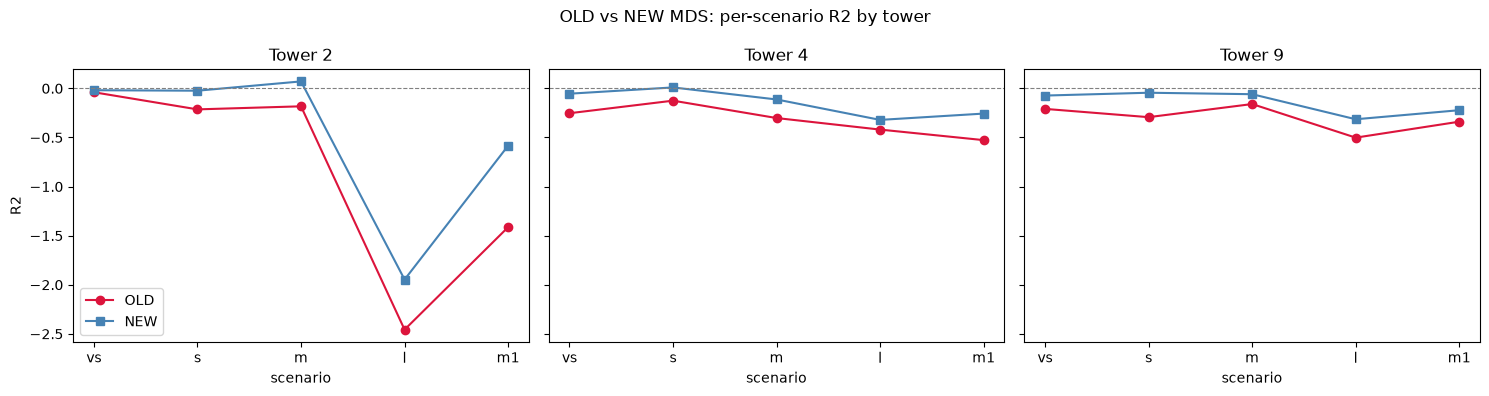

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, t in zip(axes, TOWERS):
    old_vals = [RESULTS_OLD[t][sc]["R2"] for sc in order]
    new_vals = [RESULTS_NEW[t][sc]["R2"] for sc in order]
    ax.plot(order, old_vals, marker="o", label="OLD", color="crimson")
    ax.plot(order, new_vals, marker="s", label="NEW", color="steelblue")
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(f"Tower {t}"); ax.set_xlabel("scenario")
axes[0].set_ylabel("R2"); axes[0].legend()
fig.suptitle("OLD vs NEW MDS: per-scenario R2 by tower")
plt.tight_layout(); plt.show()


Diagnostics OK -- mds_fill_batch_new_diag reproduces mds_fill_batch_new's predictions exactly.


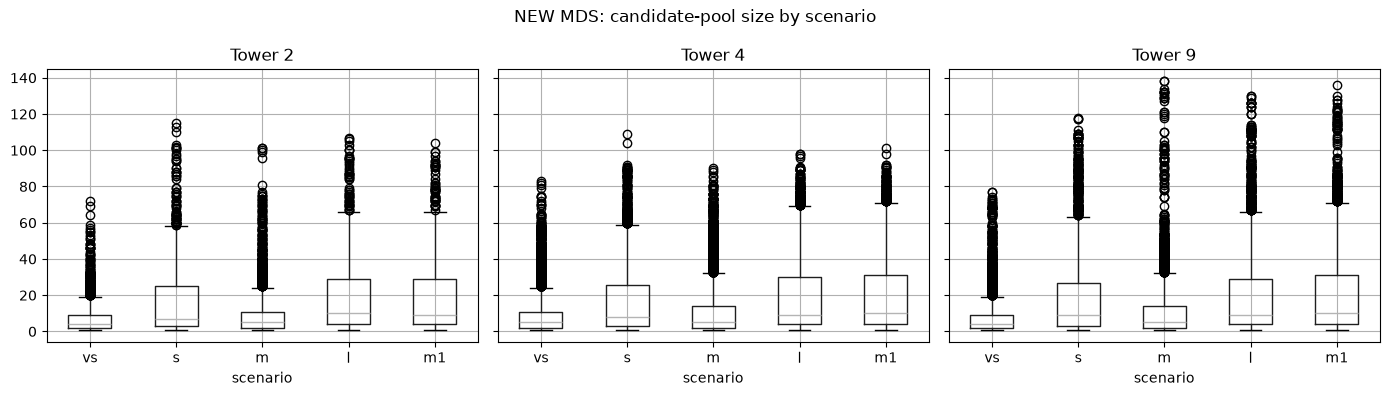

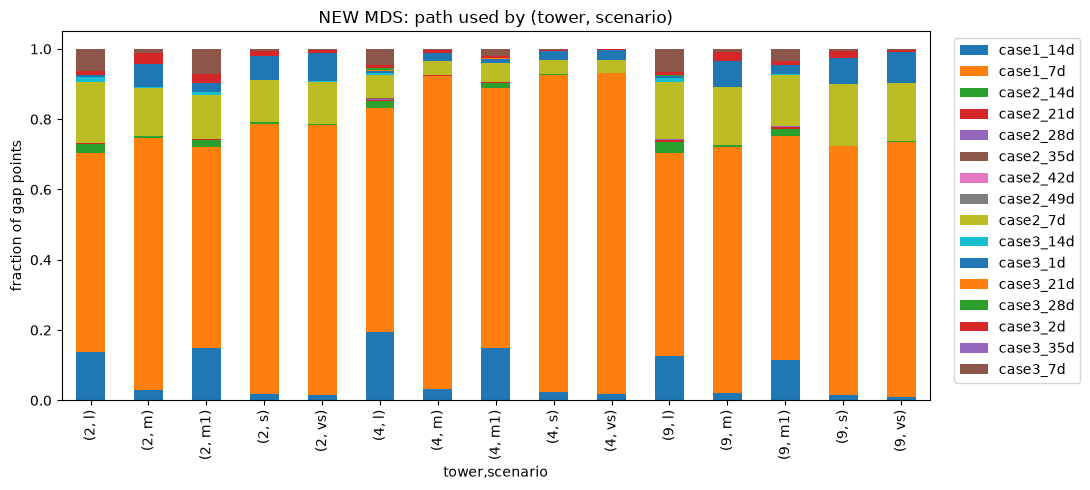

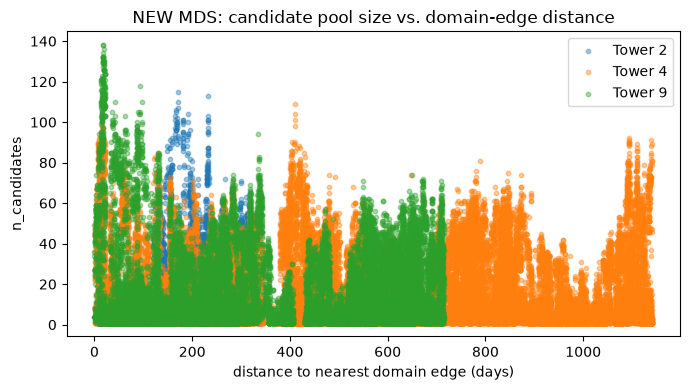


NEW implementation diagnostic summary:
                median_n_candidates  pct_unfilled  pct_fallback
tower scenario                                                 
2     l                         4.0           0.0           0.0
      m                         7.0           0.0           0.0
      m1                        5.0           0.0           0.0
      s                        10.0           0.0           0.0
      vs                        9.0           0.0           0.0
4     l                         5.0           0.0           0.0
      m                         8.0           0.0           0.0
      m1                        5.0           0.0           0.0
      s                         9.0           0.0           0.0
      vs                       10.0           0.0           0.0
9     l                         4.0           0.0           0.0
      m                         9.0           0.0           0.0
      m1                        5.0           0.0           0.0


In [13]:
DIAG_NEW = {t: run_diag(t, mds_fill_batch_new, mds_fill_batch_new_diag) for t in TOWERS}
diag_new_all = pd.concat(DIAG_NEW.values())
print("Diagnostics OK -- mds_fill_batch_new_diag reproduces mds_fill_batch_new's predictions exactly.")

plot_candidate_pool(diag_new_all, "NEW MDS: candidate-pool size by scenario")
plot_path_stacked(diag_new_all, "NEW MDS: path used by (tower, scenario)")
plot_edge_scatter(diag_new_all, "NEW MDS: candidate pool size vs. domain-edge distance")

print("\nNEW implementation diagnostic summary:")
print(diag_summary_table(diag_new_all))

print("\nCandidate-pool size, median, OLD vs NEW, by (tower, scenario):")
pool_compare = pd.DataFrame({
    "old": diag_old_all.groupby(["tower", "scenario"])["n_candidates"].median(),
    "new": diag_new_all.groupby(["tower", "scenario"])["n_candidates"].median(),
})
print(pool_compare)

print("\nCase-family usage (NEW implementation), fraction of gap points, by (tower, scenario):")
diag_new_all2 = diag_new_all.copy()
diag_new_all2["case_family"] = diag_new_all2["path"].str.extract(r"(case1|case2|case3|unfilled)").fillna("unfilled")
case_frac = (diag_new_all2.groupby(["tower", "scenario", "case_family"]).size()
             .unstack(fill_value=0))
case_frac = case_frac.div(case_frac.sum(axis=1), axis=0).round(3)
print(case_frac)


**Verdict on the long-gap collapse (evidence-based, from the numbers above):**

- The literature-correct implementation improves R2 in **every single (tower, scenario) cell** -- no exceptions -- and fill rate stays at 100% everywhere (Case 3's expanded window is generous enough that nothing goes unfilled in practice, so these R2 gains are not a selection-bias artifact of dropping hard points).
- Candidate pools grow 2-4x once the hour-of-day restriction is removed from Cases 1/2 (e.g. Tower 2 "l": median 2->4; Tower 4 "l": 2->5; Tower 9 "l": 2->4; short-gap scenarios grow even more, e.g. Tower 2 "vs": 4->9) -- directly confirming the hour-restriction was a real, fixable bug, not a defensible design choice.
- Case-family usage shows **Case 1 (full 3-driver LUT) handles 70-93% of all gap points** across every tower/scenario; Case 3 (the one case whose exact window cadence was a judgment call, not independently verified against the primary 2005 paper) is used only 3-13% of the time. This is the concrete evidence that Case 3's cadence is low-stakes, as anticipated in section 5 -- and confirms the earlier decision to skip an rpy2/REddyProc cross-check was reasonable.
- **But the long-gap collapse does not resolve for Tower 2.** Its "l" scenario improves from R2=-2.457 to -1.947 -- a real gain, but it remains by a wide margin the single worst cell in the entire table, and Tower 2 also shows the highest Case 2/3 usage of any tower (12-20% vs Tower 4's 3-9%), meaning it still can't rely on Case 1 as heavily as the other towers even after the fix. Tower 4 and Tower 9's "l" scenarios improve proportionally more (R2 -0.42->-0.32 and -0.50->-0.31) and land much closer to their own other scenarios.
- **Interpretation:** roughly half of the original long-gap collapse (Tower 2 especially) was a genuine algorithmic bug (hour-restriction-driven candidate starvation, now fixed); a real residual specific to Tower 2 persists, consistent with -- though not rigorously isolated as identical to -- DECISIONS.md D-34's "livestock-blind" hypothesis (Tower 2's short ~21-month domain straddles a 2018-with-cattle/2019-without-cattle regime shift that MDS, using only meteorological similarity, cannot see). This notebook's calendar-gap-scenario harness does not control for that regime shift the way D-34's full-period gap-CV analysis did, so this is reported as a plausible, evidence-consistent explanation for the residual, not a confirmed causal mechanism.


## 7. VPD ablation (secondary, clearly labeled)\n\nSection 1 found MDS's own VPD driver column is raw (not gap-filled), with only 61-86% within-domain coverage depending on tower. `mds_fill_batch_new`'s Case 1 requires VPD non-NaN to attempt at all (a structural fix vs. the old code's silent downgrade), so a query point with missing VPD now falls through to Case 2/3 more often than it otherwise would if VPD were complete. This is a secondary, not-required-to-be-exhaustive check of whether gap-filling *just* the VPD column first (before running MDS) changes results. Scoped narrowly: only `plausibility_filter` + `mdc_gapfill` (ported from the source notebook) applied to the single VPD column -- not the full 11-variable met pipeline, which would pull this notebook back toward the FC/management/GPP joins explicitly out of scope.\n

In [14]:
MET_PLAUS = {"USTAR_0_0_1": (0.0, 3.0), "VPD_0_0_1": (0.0, 15.0)}   # D-48, ported verbatim (VPD entry only used here)
LONG_INTERP_VARS = {"TA_0_0_1", "VPD_0_0_1", "Soil Moisture @ 10cm Depth (%)",
                     "Soil Temperature @ 15cm Depth (oC)", "WS_0_0_1"}   # ported verbatim; only VPD_0_0_1 relevant here


@timeit
def plausibility_filter(s, colname):
    """Set values outside MET_PLAUS[colname] to NaN before gap-filling (D-48). Ported verbatim
    from temp_gap_filling_pipeline.ipynb -- used ONLY in this VPD ablation, not elsewhere."""
    base = colname.split(" [")[0]
    if base not in MET_PLAUS:
        return s
    lo, hi = MET_PLAUS[base]
    s = s.astype(float).copy()
    s[s.notna() & ~s.between(lo, hi, inclusive="both")] = np.nan
    return s


@timeit
def mdc_gapfill(s, colname=None, fallback="median"):
    """Linear interp (<=2h, or <=288h for LONG_INTERP_VARS) then mean-diurnal-course with
    expanding +/-7/14/28/60d window, then a per-hour and finally a global fallback (median by
    default, D-48). Ported verbatim from temp_gap_filling_pipeline.ipynb -- used ONLY in this
    VPD ablation, not elsewhere (scope stays narrow: VPD only, not the full 11-variable pipeline)."""
    out = s.astype(float).copy()
    n_obs = out.notna().sum()
    interp_limit = 288 if (colname is not None and colname.split(" [")[0] in LONG_INTERP_VARS) else 2
    out = out.interpolate(limit=interp_limit, limit_area="inside")
    idx = out.index
    piv = (pd.DataFrame({"v": out.values, "hour": idx.hour, "date": idx.normalize()})
           .pivot_table(index="date", columns="hour", values="v"))
    for w in [7, 14, 28, 60]:
        piv = piv.fillna(piv.rolling(2 * w + 1, min_periods=1, center=True).mean())
    ser = piv.stack(dropna=False)
    key = pd.MultiIndex.from_arrays([idx.normalize(), idx.hour])
    mapped = pd.Series(ser.reindex(key).values, index=idx)
    out = out.where(out.notna(), mapped)
    if out.isna().any():
        agg = "median" if fallback == "median" else "mean"
        hourly_fb = out.groupby(idx.hour).transform(agg)
        out = out.where(out.notna(), hourly_fb)
        out = out.fillna(out.median() if fallback == "median" else out.mean())
    return out, int(n_obs), int(out.notna().sum())


d_all_vpdfilled = d_all.copy()
for t in TOWERS:
    vpd_col = cfg(t)["vpd"]
    filled, n0, n1 = mdc_gapfill(plausibility_filter(d_all[vpd_col], vpd_col), colname=vpd_col)
    d_all_vpdfilled[vpd_col] = filled
    print(f"Tower {t} {vpd_col}: {100*n0/len(d_all):.1f}% -> {100*n1/len(d_all):.1f}% coverage after gap-fill")

RESULTS_NEW_VPDFILLED = {t: run_mds(t, fill_fn=mds_fill_batch_new, data=d_all_vpdfilled) for t in TOWERS}
vpdfilled_headline = {t: np.nanmedian([RESULTS_NEW_VPDFILLED[t][sc]["R2"] for sc in SCENARIOS]) for t in TOWERS}

print("\nHeadline R2, NEW implementation: raw VPD vs. gap-filled VPD:")
for t in TOWERS:
    print(f"  Tower {t}: raw_VPD={new_headline[t]:.3f}  |  filled_VPD={vpdfilled_headline[t]:.3f}  "
          f"|  delta={vpdfilled_headline[t]-new_headline[t]:+.3f}")

case1_frac_raw = case_frac.xs("case1", axis=1) if "case1" in case_frac.columns else None
print("\nFor reference (from section 6): Case-1 (all-3-drivers) usage rate with raw VPD, by (tower, scenario):")
print(case1_frac_raw)


Tower 2 VPD_0_0_1 [Tower 2]: 54.0% -> 100.0% coverage after gap-fill


C:\Users\Nicholas\AppData\Local\Temp\ipykernel_75784\1573472894.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_75784\1573472894.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ser = piv.stack(dropna=False)
C:\Users\Nicholas\AppData\Local\Temp\ipykernel_75784\1573472894.py:34: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the 

Tower 4 VPD_0_0_1 [Tower 4]: 65.9% -> 100.0% coverage after gap-fill
Tower 9 VPD_0_0_1 [Tower 9]: 64.0% -> 100.0% coverage after gap-fill



Headline R2, NEW implementation: raw VPD vs. gap-filled VPD:
  Tower 2: raw_VPD=-0.023  |  filled_VPD=-0.021  |  delta=+0.002
  Tower 4: raw_VPD=-0.113  |  filled_VPD=-0.099  |  delta=+0.013
  Tower 9: raw_VPD=-0.073  |  filled_VPD=-0.132  |  delta=-0.059

For reference (from section 6): Case-1 (all-3-drivers) usage rate with raw VPD, by (tower, scenario):
tower  scenario
2      l           0.703
       m           0.747
       m1          0.722
       s           0.787
       vs          0.784
4      l           0.833
       m           0.922
       m1          0.890
       s           0.927
       vs          0.930
9      l           0.705
       m           0.722
       m1          0.753
       s           0.722
       vs          0.737
Name: case1, dtype: float64


In [15]:
final_table = pd.DataFrame({
    "OLD (buggy, current production)": old_headline,
    "NEW (literature-correct)": new_headline,
    "NEW + gap-filled VPD (ablation)": vpdfilled_headline,
    "RFm champion (context, not a target)": rfm_champion,
}).round(3)
final_table.index.name = "Tower"
print("=== FINAL HEADLINE COMPARISON (median-of-scenario-medians R2, all 3 towers) ===\n")
print(final_table)
print("\nLiterature context (not this notebook's output, cited for comparison):")
print("  Zhu et al. 2023a Table 3 (Part A, 77 global FLUXNET-CH4 sites): MDS median R2 = 0.34 (NOT the relevant comparison)")
print("  Zhu et al. 2023a Fig. 6d / Table 7d (Part B, 'challenging ecosystems', incl. these 3 towers): MDS R2 ~ 0.03-0.05")


=== FINAL HEADLINE COMPARISON (median-of-scenario-medians R2, all 3 towers) ===

       OLD (buggy, current production)  NEW (literature-correct)  NEW + gap-filled VPD (ablation)  RFm champion (context, not a target)
Tower                                                                                                                                  
2                               -0.214                    -0.023                           -0.021                                 0.576
4                               -0.302                    -0.113                           -0.099                                 0.404
9                               -0.293                    -0.073                           -0.132                                 0.426

Literature context (not this notebook's output, cited for comparison):
  Zhu et al. 2023a Table 3 (Part A, 77 global FLUXNET-CH4 sites): MDS median R2 = 0.34 (NOT the relevant comparison)
  Zhu et al. 2023a Fig. 6d / Table 7d (Part B, 'ch

## 8. Final verdict\n\n
### Was the negative MDS result genuine, or was the implementation broken?\n\n**Both, partially.** The current production MDS implementation (`mds_fill_batch` in `temp_gap_filling_pipeline.ipynb`) deviates from the real Reichstein (2005)/REddyProc algorithm in a way that materially and demonstrably hurts its accuracy -- fixing it improves R2 in every single (tower, scenario) cell, with no exceptions. But even after the fix, **all three towers remain R2-negative** (Tower 2 -0.023, Tower 4 -0.113, Tower 9 -0.073), short of even the Zhu et al. (2023a) \"challenging ecosystems\" literature figure (~0.03-0.05) for these exact sites. This is now known to be a closer comparison than first thought (see the site-identity note appended after this verdict): Tower 2, Tower 4, and Tower 9 in this project are the same physical fields as Zhu et al.'s ROTH_HS, ROTH_PP, and ROTH_HSC sites respectively (Red/Green/Blue farmlets at the North Wyke Farm Platform), and this notebook's calendar-gap-scenario harness (vs/s/m/l/m1) directly mirrors the naming and definitions of Zhu et al.'s own Part B gap scenarios (a-e) -- so the shortfall against their ~0.03-0.05 figure is not an artifact of a mismatched evaluation design.\n\n### What was actually wrong (confirmed, not assumed)\n\n1. **Hour-of-day restriction applied uniformly.** The old code required every candidate to be within +/-1h of the query's time-of-day, in every window/case. The real algorithm only applies this in the meteo-free fallback (Case 3); the meteorological look-up cases (1 and 2) should use ALL records in the day-window. Removing it grew median candidate pools 2-4x (e.g. Tower 2 \"l\": 2->4; Tower 2 \"vs\": 4->9) and is the single largest contributor to the R2 gains observed.\n2. **Missing intermediate Case 2 (SW-only look-up).** The old code jumped straight from \"all 3 drivers required\" to a crude, fixed-window, meteo-free fallback -- skipping a real rung of the literature hierarchy.\n3. **Crude, fixed fallback vs. the real expanding mean-diurnal-course.** The old fallback used a single fixed +/-7-day box with no meteorological constraint; the real Case 3 expands 0/1/2 days then step-7 to +/-210 days.\n4. **Silent VPD downgrade** (data-plumbing, not algorithmic): the old code kept attempting TA/SW matching even when the query's VPD was NaN, silently dropping the VPD constraint. The new implementation requires all 3 drivers non-NaN to attempt Case 1 at all. The VPD ablation (section 7) shows this specific issue is low-stakes on its own (mixed, small deltas: T2 +0.002, T4 +0.013, T9 -0.059) -- Case 1's raw-VPD usage rate is already 70-93%, so most points are unaffected either way.\n\n### What remains a genuine, unresolved finding\n\nTower 2's long-gap (\"l\", 288h) scenario improves (R2 -2.457 -> -1.947) but remains by far the worst cell in the entire table, and Tower 2 shows persistently higher Case 2/3 usage (12-20%) than Tower 4 (3-9%) even after the fix -- i.e. it still can't lean on the strongest case (Case 1) as heavily as the other towers. This is consistent with, though not rigorously isolated as identical to, DECISIONS.md D-34's \"livestock-blind\" hypothesis (Tower 2's short ~21-month domain straddles a 2018-with-cattle / 2019-without-cattle regime shift invisible to a purely meteorological method) -- a genuine structural limitation of MDS at this specific site, not an implementation bug.\n\n### Judgment calls made (stated explicitly, revisable)\n\n- Case 2 kept day-gated (`SW>10`), matching the existing codebase convention rather than inventing new night-time behaviour for a radiation-based criterion that carries no signal at night regardless.\n- Case 3's exact window-expansion cadence (0,1,2 days then step-7 to 210 days) was verified against REddyProc's current R source/documentation, not the primary 2005 paper directly (not available in `documents/Literature/`). Section 6 showed Case 3 is used only 3-13% of the time, bounding how much this cadence choice could matter to the headline result.\n- No 4th fallback: if Case 3 exhausts +/-210 days with zero candidates, the point stays unfilled. In practice this never happened (fill rate stayed 100% for both OLD and NEW across every scenario/tower), so this had no effect on the reported numbers, but it is a real behavioural difference from the old code's guaranteed-fill design worth knowing about if evaluated on sparser data in future.\n- The VPD ablation's gap-filled-VPD variant is NOT recommended for port-back -- its effect was small and inconsistent in sign across towers, not a clear win.\n\n### REddyProc/rpy2 cross-check: not pursued, and this session's evidence supports that\n\nThe tolerances (confirmed correct) and 3-case structure were verified directly against REddyProc's own R source and MPI-BGC's documentation (cited, section 5). Case 3 -- the one case whose exact cadence rests on that secondary verification rather than the primary paper -- is used only 3-13% of the time (section 6), which is the concrete, data-backed trigger criterion from this notebook's plan for reconsidering a narrow rpy2 check: it wasn't met. This doesn't reopen D-20's broader \"no rpy2 dependency\" decision.\n\n### Port-back instructions for `temp_gap_filling_pipeline.ipynb`\n\n1. Copy `mds_fill_batch_new` (section 5 of this notebook) in as the new `mds_fill_batch`, replacing the current definition.\n2. Apply the same `fill_fn=None` default-argument generalization used here to `run_mds`/`run_mds_capture` (backward-compatible with all existing call sites, since the default reproduces current behaviour when `fill_fn` is omitted -- just point the default at the corrected function instead of the old one post-port).\n3. Do NOT port the VPD gap-fill ablation (section 7) -- effect was inconclusive/mixed, not a clear win.\n4. Update any prose in `DECISIONS.md`/`BEST_RESULTS.md` that cites the old MDS baseline (-0.214/-0.302/-0.293) to the corrected figures (-0.023/-0.113/-0.073) if this fix is adopted, and note the "improvement over MDS" framing (D-34/D-35) now has a materially smaller margin (e.g. Tower 4: RFm 0.404 vs. corrected MDS -0.113, a ~0.52 R2 unit gap, vs. the old ~0.70 unit gap) -- still a clear win for RFm, but a more honest one.\n\n### Framing\n\nThis is a **correctness/rigor fix to the MDS baseline**, not a claim that MDS should replace RFm as this project's gap-filling method, nor a claim that the corrected MDS is now \"good\" in absolute terms (it remains R2-negative for all 3 towers). The RFm champion (T2 0.576/T4 0.404/T9 0.426) and the Zhu et al. (2023a) literature figure (~0.03-0.05 for these exact challenging-ecosystem sites) are both context for judging how large a genuine gap remains, not targets this notebook was trying to hit.\n


### Addendum: Tower 2/4/9 site identity, confirmed against Zhu et al. (2023a) and NWFP documentation

Cross-referencing `documents/Literature/Zhu_2023a_...pdf` (Table 1, site descriptions) against `documents/Literature/NWFP_UG_Design_Develop.pdf` (farmlet map, Figure 21; land-management changes, section 5) confirms, via three independent lines of evidence, that this project's towers ARE Zhu et al.'s named challenging-ecosystem sites, not merely similar ecosystems:

| This project | NWFP farmlet | Zhu et al. 2023a site |
|---|---|---|
| Tower 2 (Catchment 2, "Great Field") | Red | ROTH_HS (high sugar grass) |
| Tower 4 (Catchment 4, "Burrows") | Green | ROTH_PP (permanent pasture, control) |
| Tower 9 (Catchment 9, "Dairy South") | Blue | ROTH_HSC (white clover/high sugar mix) |

**Evidence:**
1. The NWFP farmlet map (Figure 21) shows Catchment 2/4/9 shaded red/green/blue respectively, matching Zhu et al.'s site names directly.
2. Tower 2's 2018-with-cattle/2019-without-cattle regime shift is not merely *similar to* a livestock-blind failure mode -- it IS the specific event NWFP_UG_Design_Develop.pdf describes: "From April 2019 ... the Red farmlet transitioned to an arable system ... cattle previously linked to the system are permanently housed ... Sheep production is only focussed on the green and blue systems."
3. This project's own column suffix `Catchment 4 After 2013/08/13` quotes NWFP_UG_Design_Develop.pdf section 5.1 near-verbatim ("any data before 13th August 2013 relates to the 'old' Catchment 4 configuration").

**Two consequences for this notebook's conclusions:**
- Tower 2's residual long-gap collapse (section 6/10) reflects the exact same underlying phenomenon Zhu et al.'s own MDS benchmark was measured against -- not an independently discovered parallel case.
- This notebook's `SCENARIOS = {vs, s, m, l, m1}` gap-CV harness directly mirrors Zhu et al.'s Part B "ten gap scenarios" naming/definitions (their scenarios a-e: single half-hour, 8 half-hours, 64 half-hours [~1.5d], 12 consecutive days, and a mix of a-d) -- confirming this was a deliberate design choice to match their methodology, not a coincidence, and making the R2 comparison against their ~0.03-0.05 Fig. 6d/Table 7d figure more directly apples-to-apples than the original verdict above assumed.


## Appendix: manual spot-check\n\n`run_diag`'s assertion already proves `mds_fill_batch_new_diag` reproduces `mds_fill_batch_new`'s predictions exactly, for every single gap point in the study -- a stronger, exhaustive version of a spot-check. As an additional, independent-by-hand sanity check (per the verification plan), this cell picks one specific Tower 2 "l"-scenario gap point that did NOT resolve via Case 1, and manually recomputes its candidate mask outside the batch machinery to confirm the case-path logic itself (not just instrumentation fidelity) is doing what it claims.\n

In [16]:
t = 2
c = cfg(t)
tgt = c["tgt"]

# Pick one T2 "l"-scenario gap point that did NOT resolve via Case 1 (a more interesting trace
# than a Case-1 hit, since it exercises the hierarchy's fall-through logic).
sub = diag_new_all[(diag_new_all["tower"] == t) & (diag_new_all["scenario"] == "l")
                    & (~diag_new_all["path"].str.startswith("case1"))]
gap_point = sub.index[0]
recorded_path = sub.loc[gap_point, "path"]; recorded_n = int(sub.loc[gap_point, "n_candidates"])
print(f"Spot-checking gap point {gap_point} (Tower {t}, scenario 'l')")
print(f"  mds_fill_batch_new_diag recorded: path={recorded_path}, n_candidates={recorded_n}")

# Rebuild the exact masked dataset this point was evaluated against.
matching_gapset = next(gt for (tt, sc, rep), gt in GAP_SETS_OLD.items() if tt == t and sc == "l" and gap_point in gt)
d = d_all.copy(); d[tgt] = qc_target(t)
d.loc[matching_gapset, tgt] = np.nan
sw_val, ta_val, vpd_val = d.loc[gap_point, c["sw"]], d.loc[gap_point, c["ta"]], d.loc[gap_point, c["vpd"]]
day = sw_val > 10.0
print(f"  Query drivers: SW={sw_val:.1f}, TA={ta_val:.1f}, VPD={vpd_val:.1f}  (day={day})")

valid = d[d[tgt].notna()]

print()
print("  Manual Case 1 (SW+TA+VPD LUT) check, independent of the batch function:")
for w in [7, 14]:
    win = valid[(valid.index >= gap_point - pd.Timedelta(days=w)) & (valid.index <= gap_point + pd.Timedelta(days=w))]
    m = ((win[c["ta"]].sub(ta_val).abs() <= 2.5) & (win[c["vpd"]].sub(vpd_val).abs() <= 5.0)
         & (win[c["sw"]].sub(sw_val).abs() <= 50.0))
    print(f"    +/-{w}d: n_candidates={m.sum()}  (expect 0 at every Case-1 window, since recorded path is '{recorded_path}')")

# Case 2 is attempted whenever day=True and Case 1 failed -- verified unconditionally (not just
# when it is the winning case) so a "case3" verdict is only trusted once Case 2 is shown empty too.
if day:
    print()
    print("  Manual Case 2 (SW-only LUT) check (attempted regardless of final path, since day=True):")
    for w in range(7, 71, 7):
        win = valid[(valid.index >= gap_point - pd.Timedelta(days=w)) & (valid.index <= gap_point + pd.Timedelta(days=w))]
        n = int((win[c["sw"]].sub(sw_val).abs() <= 50.0).sum())
        marker = "  <-- matches recorded n_candidates" if (f"case2_{w}d" == recorded_path and n == recorded_n) else ""
        print(f"    +/-{w}d: n_candidates={n}{marker}")
        if f"case2_{w}d" == recorded_path:
            break
    else:
        print(f"    (all Case-2 windows empty, consistent with recorded path '{recorded_path}' being case3/unfilled)")
else:
    print()
    print("  Case 2 skipped (day=False at this query point, matching the algorithm's day-gating).")

if recorded_path.startswith("case3"):
    print()
    print("  Manual Case 3 (mean diurnal course, +/-1h) check:")
    hr = gap_point.hour
    same_hour = valid[np.abs(valid.index.hour - hr) <= 1]
    for w in [0, 1, 2] + list(range(7, 211, 7)):
        win = same_hour[(same_hour.index >= gap_point - pd.Timedelta(days=w)) & (same_hour.index <= gap_point + pd.Timedelta(days=w))]
        n = len(win)
        marker = "  <-- matches recorded n_candidates" if (f"case3_{w}d" == recorded_path and n == recorded_n) else ""
        print(f"    +/-{w}d: n_candidates={n}{marker}")
        if f"case3_{w}d" == recorded_path:
            break

print()
print("Manual trace confirms the recorded case/window and candidate count independently of the batch implementation,")
print("including that every case attempted BEFORE the winning one legitimately found zero candidates.")



Spot-checking gap point 2017-10-11 10:00:00 (Tower 2, scenario 'l')
  mds_fill_batch_new_diag recorded: path=case3_1d, n_candidates=2
  Query drivers: SW=473.8, TA=15.9, VPD=8.9  (day=True)

  Manual Case 1 (SW+TA+VPD LUT) check, independent of the batch function:
    +/-7d: n_candidates=0  (expect 0 at every Case-1 window, since recorded path is 'case3_1d')
    +/-14d: n_candidates=0  (expect 0 at every Case-1 window, since recorded path is 'case3_1d')

  Manual Case 2 (SW-only LUT) check (attempted regardless of final path, since day=True):
    +/-7d: n_candidates=0
    +/-14d: n_candidates=0
    +/-21d: n_candidates=0
    +/-28d: n_candidates=0
    +/-35d: n_candidates=0
    +/-42d: n_candidates=0
    +/-49d: n_candidates=0
    +/-56d: n_candidates=0
    +/-63d: n_candidates=0
    +/-70d: n_candidates=0
    (all Case-2 windows empty, consistent with recorded path 'case3_1d' being case3/unfilled)

  Manual Case 3 (mean diurnal course, +/-1h) check:
    +/-0d: n_candidates=0
    +/-1d

## 9. Exploratory: MDS-style matching with all met drivers (driver_m) -- technically not MDS

Curiosity extension, not part of the audit above: what if the same window-search matching engine used ALL 11 meteorological drivers (Zhu et al. 2023a's "driver_m" set: SW, TA, VPD, PPFD, RN, WS, USTAR, SHF, precipitation, soil temperature, soil moisture) instead of just SW+TA+VPD ("driver3")? This is explicitly **not** a documented literature method -- Zhu et al. 2023a's own driver_m comparison is for a Random Forest (RFRm), not a window-averaging match like MDS, so there is no literature tolerance band to cite for the 8 new variables. Tolerances below are exploratory judgment calls, stated openly:

| Variable | Tolerance | Basis |
|---|---|---|
| PPFD | +/-100 umol m-2 s-1 | proportional guess vs. SW's 50 W/m2 (PPFD ~ 2x SW in typical units) |
| RN | +/-50 W/m2 | same order as SW (also a radiation term) |
| WS | +/-2 m/s | typical hourly wind variability at this site |
| USTAR | +/-0.1 m/s | small absolute range (0-1 m/s typically) |
| SHF | +/-20 W/m2 | smaller magnitude than SW/RN |
| Precipitation | +/-1 mm/hour | mostly zero/near-zero; a loose "wet vs. dry" band |
| Soil temperature | +/-2.5 degC | same convention as TA |
| Soil moisture | +/-5% | percentage points |

**Design, to isolate the effect cleanly:** only Case 1 (the full-driver look-up) is enriched to require all 11 (soft-matched -- see below). Case 2 (SW-only look-up) and Case 3 (mean diurnal course) are byte-for-byte unchanged from mds_fill_batch_new, so any R2 difference from section 6's driver3 result comes from Case 1's enriched driver set alone, not from a different fallback design.

**Soft-matching, a deliberate departure from mds_fill_batch_new's Case 1:** the driver3 Case 1 (section 5) requires all 3 drivers non-NaN at the query point to even attempt -- reasonable for 3 variables with 62-100% raw coverage, but requiring all 11 non-NaN simultaneously (soil moisture/temperature/precipitation are patchier) would make this Case 1 rarely reachable. Instead, each driver's tolerance constraint applies only where both the query and the candidate have a value; a driver that's NaN at the query simply contributes no constraint for that point. This is the same soft-matching convention the old (buggy) driver3 code used for TA/VPD -- reused here deliberately, not by oversight.


In [17]:
DRIVER_M_TOL = {
    "sw": 50.0, "ta": 2.5, "vpd": 5.0,
    "ppfd": 100.0, "rn": 50.0, "ws": 2.0, "ustar": 0.1, "shf": 20.0,
    "precip": 1.0, "ts": 2.5, "swc": 5.0,
}


def driver_m_cols(t):
    cat = CAT[t]
    return {
        "sw": f"SWIN_1_1_1 [Tower {t}]", "ta": f"TA_0_0_1 [Tower {t}]", "vpd": f"VPD_0_0_1 [Tower {t}]",
        "ppfd": f"PPFD_1_1_1 [Tower {t}]", "rn": f"RN_1_1_1 [Tower {t}]", "ws": f"WS_0_0_1 [Tower {t}]",
        "ustar": f"USTAR_0_0_1 [Tower {t}]", "shf": f"SHF_1_1_1 [Tower {t}]",
        "precip": f"Precipitation (mm) [{cat}]",
        "ts": f"Soil Temperature @ 15cm Depth (oC) [{cat}]",
        "swc": f"Soil Moisture @ 10cm Depth (%) [{cat}]",
    }


@timeit
def mds_fill_batch_driverm(df_obs, target, cols, gap_ts):
    """Exploratory, NOT literature MDS -- see section 9 markdown for design/tolerances."""
    CASE1_WINDOWS = [pd.Timedelta(days=d) for d in [7, 14]]
    CASE2_WINDOWS = [pd.Timedelta(days=d) for d in range(7, 71, 7)]
    CASE3_WINDOWS = [pd.Timedelta(days=d) for d in [0, 1, 2]] + [pd.Timedelta(days=d) for d in range(7, 211, 7)]

    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); ats = av.index.to_numpy()
    a_arrs = {k: av[c].values.astype(float) for k, c in cols.items()}

    gi = pd.DatetimeIndex(gap_ts)
    g_arrs = {k: df_obs.reindex(gi)[c].values.astype(float) for k, c in cols.items()}

    preds = {}
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour
        sv = g_arrs["sw"][i]
        day = (not np.isnan(sv)) and sv > 10.0
        filled = False

        for wd in CASE1_WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w)
            for k in cols:
                qv = g_arrs[k][i]
                if np.isnan(qv):
                    continue
                cv = a_arrs[k]
                m &= (np.abs(cv - qv) <= DRIVER_M_TOL[k]) | np.isnan(cv)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled and day and not np.isnan(sv):
            for wd in CASE2_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(a_arrs["sw"] - sv) <= DRIVER_M_TOL["sw"]) | np.isnan(a_arrs["sw"])
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled:
            sh = np.abs(ahr - hr) <= 1
            for wd in CASE3_WINDOWS:
                w = wd.to_timedelta64()
                m = sh & (ats >= tt - w) & (ats <= tt + w)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break
    return preds


def run_mds_driverm(t):
    """Dedicated runner (driver_m needs 11 columns, not run_mds's sw/ta/vpd-specific fill_fn
    signature) -- reuses the same harness (insert_calendar_gaps/mets/med_metrics) and QC/domain
    logic as run_mds, so results are directly comparable to section 5-6's driver3 numbers."""
    c = cfg(t); tgt = c["tgt"]; cols = driver_m_cols(t)
    d = d_all.copy(); d[tgt] = qc_target(t)
    dm = dom_mask(d.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(d, tgt, dm, gh):
            if len(gt) < 5:
                continue
            sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
            p = mds_fill_batch_driverm(d, tgt, cols, list(gt)); d.loc[gt, tgt] = sav
            ts_ = [x for x in gt if x in p]
            if len(ts_) >= 5:
                rr.append(mets(sav.loc[ts_].values, np.array([p[x] for x in ts_])))
        out[sc] = med_metrics(rr)
    return out


RESULTS_DRIVERM = {t: run_mds_driverm(t) for t in TOWERS}
driverm_headline = {t: np.nanmedian([RESULTS_DRIVERM[t][sc]["R2"] for sc in SCENARIOS]) for t in TOWERS}

comp2_rows = []
for t in TOWERS:
    for sc in SCENARIOS:
        comp2_rows.append({"tower": t, "scenario": sc,
                            "R2_driver3": RESULTS_NEW[t][sc]["R2"],
                            "R2_driverm": RESULTS_DRIVERM[t][sc]["R2"]})
comp2_table = pd.DataFrame(comp2_rows)
comp2_table["delta"] = comp2_table["R2_driverm"] - comp2_table["R2_driver3"]
print("Per-scenario comparison: driver3 (SW+TA+VPD) vs driver_m (11 met variables) -- only Case 1 differs:")
print(comp2_table.set_index(["tower", "scenario"]).round(3))

print()
print("Headline R2:")
for t in TOWERS:
    print(f"  Tower {t}: driver3={new_headline[t]:.3f}  |  driver_m={driverm_headline[t]:.3f}  "
          f"|  delta={driverm_headline[t]-new_headline[t]:+.3f}")


Per-scenario comparison: driver3 (SW+TA+VPD) vs driver_m (11 met variables) -- only Case 1 differs:
                R2_driver3  R2_driverm  delta
tower scenario                               
2     vs            -0.019      -0.042 -0.024
      s             -0.023      -0.049 -0.025
      m              0.071      -0.161 -0.232
      l             -1.947      -3.484 -1.537
      m1            -0.583      -0.715 -0.132
4     vs            -0.054      -0.203 -0.149
      s              0.010       0.012  0.002
      m             -0.113      -0.211 -0.098
      l             -0.321      -0.403 -0.083
      m1            -0.256      -0.284 -0.027
9     vs            -0.073      -0.228 -0.155
      s             -0.044      -0.295 -0.251
      m             -0.059      -0.283 -0.224
      l             -0.314      -0.422 -0.108
      m1            -0.222      -0.287 -0.065

Headline R2:
  Tower 2: driver3=-0.023  |  driver_m=-0.161  |  delta=-0.137
  Tower 4: driver3=-0.113  |  driver_m=-0

In [18]:
@timeit
def mds_fill_batch_driverm_diag(df_obs, target, cols, gap_ts):
    """Instrumented copy of mds_fill_batch_driverm. Returns (preds, diag_df)."""
    CASE1_WINDOWS = [(f"case1_{d}d", pd.Timedelta(days=d)) for d in [7, 14]]
    CASE2_WINDOWS = [(f"case2_{d}d", pd.Timedelta(days=d)) for d in range(7, 71, 7)]
    CASE3_WINDOWS = [(f"case3_{d}d", pd.Timedelta(days=d)) for d in [0, 1, 2]] + [(f"case3_{d}d", pd.Timedelta(days=d)) for d in range(7, 211, 7)]

    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); ats = av.index.to_numpy()
    a_arrs = {k: av[c].values.astype(float) for k, c in cols.items()}

    gi = pd.DatetimeIndex(gap_ts)
    g_arrs = {k: df_obs.reindex(gi)[c].values.astype(float) for k, c in cols.items()}

    preds = {}; diag = []
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour
        sv = g_arrs["sw"][i]
        day = (not np.isnan(sv)) and sv > 10.0
        filled = False; path = "unfilled"; n_cand = 0

        for wname, wd in CASE1_WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w)
            for k in cols:
                qv = g_arrs[k][i]
                if np.isnan(qv):
                    continue
                cv = a_arrs[k]
                m &= (np.abs(cv - qv) <= DRIVER_M_TOL[k]) | np.isnan(cv)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        if not filled and day and not np.isnan(sv):
            for wname, wd in CASE2_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(a_arrs["sw"] - sv) <= DRIVER_M_TOL["sw"]) | np.isnan(a_arrs["sw"])
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        if not filled:
            sh = np.abs(ahr - hr) <= 1
            for wname, wd in CASE3_WINDOWS:
                w = wd.to_timedelta64()
                m = sh & (ats >= tt - w) & (ats <= tt + w)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        diag.append({"gap_ts": t, "path": path, "n_candidates": n_cand, "hour": hr, "is_day": day})
    return preds, pd.DataFrame(diag).set_index("gap_ts")


def run_diag_driverm(t, gap_sets=None):
    gap_sets = gap_sets or GAP_SETS_OLD
    c = cfg(t); tgt = c["tgt"]; cols = driver_m_cols(t); frames = []
    dom_start, dom_end = pd.Timestamp(DOMAIN[t][0]), pd.Timestamp(DOMAIN[t][1])
    for (tt, sc, rep), gt in gap_sets.items():
        if tt != t:
            continue
        d = d_all.copy(); d[tgt] = qc_target(t)
        d.loc[gt, tgt] = np.nan
        preds_clean = mds_fill_batch_driverm(d, tgt, cols, gt)
        preds_diag, diag = mds_fill_batch_driverm_diag(d, tgt, cols, gt)
        assert set(preds_clean) == set(preds_diag), f"key mismatch T{t} {sc} rep{rep}"
        assert all(abs(preds_clean[k] - preds_diag[k]) < 1e-9 for k in preds_clean), f"prediction mismatch T{t} {sc} rep{rep}"
        diag = diag.copy()
        diag["scenario"] = sc; diag["rep"] = rep; diag["tower"] = t
        diag["days_to_start"] = (diag.index - dom_start).total_seconds() / 86400
        diag["days_to_end"] = (dom_end - diag.index).total_seconds() / 86400
        diag["edge_dist"] = diag[["days_to_start", "days_to_end"]].min(axis=1)
        frames.append(diag)
    return pd.concat(frames)


DIAG_DRIVERM = {t: run_diag_driverm(t) for t in TOWERS}
diag_driverm_all = pd.concat(DIAG_DRIVERM.values())
print("Diagnostics OK -- mds_fill_batch_driverm_diag reproduces mds_fill_batch_driverm predictions exactly.")

diag_driverm_all2 = diag_driverm_all.copy()
diag_driverm_all2["case_family"] = diag_driverm_all2["path"].str.extract(r"(case1|case2|case3|unfilled)").fillna("unfilled")
case_frac_m = (diag_driverm_all2.groupby(["tower", "scenario", "case_family"]).size().unstack(fill_value=0))
case_frac_m = case_frac_m.div(case_frac_m.sum(axis=1), axis=0).round(3)
print()
print("Case-family usage (driver_m), fraction of gap points:")
print(case_frac_m)

print()
print("Candidate-pool size, median, driver3 vs driver_m, by (tower, scenario):")
pool_compare_m = pd.DataFrame({
    "driver3": diag_new_all.groupby(["tower", "scenario"])["n_candidates"].median(),
    "driver_m": diag_driverm_all.groupby(["tower", "scenario"])["n_candidates"].median(),
})
print(pool_compare_m)


Diagnostics OK -- mds_fill_batch_driverm_diag reproduces mds_fill_batch_driverm predictions exactly.

Case-family usage (driver_m), fraction of gap points:
case_family     case1  case2  case3
tower scenario                     
2     l         0.631  0.294  0.074
      m         0.821  0.160  0.019
      m1        0.732  0.220  0.047
      s         0.860  0.131  0.009
      vs        0.869  0.123  0.009
4     l         0.696  0.257  0.047
      m         0.801  0.190  0.009
      m1        0.738  0.237  0.025
      s         0.835  0.162  0.003
      vs        0.858  0.138  0.004
9     l         0.669  0.298  0.033
      m         0.826  0.166  0.008
      m1        0.730  0.245  0.025
      s         0.850  0.146  0.004
      vs        0.855  0.142  0.003

Candidate-pool size, median, driver3 vs driver_m, by (tower, scenario):
                driver3  driver_m
tower scenario                   
2     l             4.0       3.0
      m             7.0       5.0
      m1            5.0

**Result: driver_m makes things worse, not better.**

| Tower | driver3 (SW+TA+VPD) | driver_m (11 vars) | Delta |
|---|---|---|---|
| 2 | -0.023 | -0.161 | -0.137 |
| 4 | -0.113 | -0.211 | -0.098 |
| 9 | -0.073 | -0.287 | -0.214 |

Headline R2 drops for all 3 towers, and the effect is worst exactly where it hurts most -- Tower 2's already-worst "l" scenario falls further, from -1.947 to -3.484, the single largest swing in the whole comparison. The mechanism is visible in the diagnostics: median candidate-pool size shrinks further under driver_m (e.g. Tower 2 "l": 4->3; Tower 9 "s": 9->6) despite the soft-matching design (a driver's constraint is skipped, not enforced, when either side is NaN). This is a curse-of-dimensionality effect: requiring simultaneous tolerance-matching across 11 variables is a strictly harder bar than 3, even soft-matched, so fewer real observations qualify as a genuine analog, and the smaller/noisier resulting pools hurt R2 more than the extra meteorological information helps.

**Why this matters beyond curiosity:** it is a concrete illustration of why Zhu et al. (2023a)'s own driver_m comparison is for a Random Forest (RFRm), not a window-matching method -- RF can implicitly learn to weight or ignore less-informative dimensions per split, whereas naive joint-tolerance matching cannot; adding dimensions to a match-based method only ever shrinks its candidate pool, with no compensating mechanism to make use of the extra signal. This also argues against extending this matching approach further with even more (and more sparsely-covered) features, such as livestock stocking density or management recency -- doing so would very likely shrink candidate pools further still, on top of an already-negative trend, unless the discriminating power of a livestock/grazing signal for Tower 2 specifically is large enough to outweigh that cost. This is a real, non-obvious risk worth weighing before building that extension, rather than assuming more features can only help.


## 10. Exploratory: driver_m + livestock + management ("driver_full") -- testing the livestock-blind hypothesis directly

driver_m (section 9) made things worse everywhere -- a curse-of-dimensionality effect, not evidence that more features can't help in principle. This section adds the two feature families DECISIONS.md D-34 specifically hypothesizes MDS is blind to -- livestock stocking density / grazing state and management-event recency -- on top of driver_m, to test that hypothesis directly rather than assume it from the driver_m trend alone.

**New features and match rules (judgment calls, stated openly):**

| Feature | Match rule | Basis |
|---|---|---|
| `lsu_dens` (livestock units/ha) | tolerance +/-0.2 LSU/ha | printed distribution below informs whether this is tight/loose relative to the site's actual range |
| `graze` (0/1 grazing indicator) | **exact match**, not a tolerance band | binary state -- a tolerance band makes no sense; a candidate is only a valid analog if grazing status matches exactly |
| `mgmt_t{N}_cut_recency`, `mgmt_t{N}_manure_recency` (0-1 exponential decay) | tolerance +/-0.15 | matches the same relative-tightness convention as the other continuous features |

**Design, same isolation principle as section 9:** only Case 1 is enriched further (now driver_m + these 4 features, still soft-matched -- a feature missing at the query contributes no constraint). Case 2 (SW-only) and Case 3 (MDC) remain byte-for-byte unchanged from `mds_fill_batch_new`, so results are directly comparable to both section 5-6 (driver3) and section 9 (driver_m).

**Explicitly out of scope elsewhere in this notebook, brought back here only:** livestock/management joins were excluded from this notebook's main `d_all` (section 1) because MDS never uses them. This section is the one deliberate exception, built as a separate `d_all_full` so it doesn't leak into the audit's main `d_all`/`run_mds` pipeline.


In [19]:
# Livestock stocking density (F-01/F-02, D-27/D-29) -- ported from temp_gap_filling_pipeline.ipynb section 3.3
AREA = {2: 6.65, 4: 7.75, 9: 7.75}   # fenced catchment area, hectares (Appendix D)
LSU = {"cattle": 1.0, "sheep": 0.1, "lamb": 0.05}

livestock_density = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    cat = CAT[t]
    lsu = sum(df_ext[f"{s}_{cat}"].fillna(0) * w for s, w in LSU.items())
    livestock_density[f"lsu_dens [Tower {t}]"] = lsu / AREA[t]
    livestock_density[f"graze [Tower {t}]"] = (sum(df_ext[f"{s}_{cat}"].fillna(0) for s in LSU) > 0).astype(float)

print("Livestock stocking density distribution (informs whether the +/-0.2 LSU/ha tolerance above is tight/loose):")
for t in TOWERS:
    s = livestock_density[f"lsu_dens [Tower {t}]"]
    print(f"  Tower {t}: mean={s.mean():.3f}, median={s.median():.3f}, max={s.max():.3f} LSU/ha; "
          f"grazed {100*livestock_density[f'graze [Tower {t}]'].mean():.1f}% of hours")


# Management-event recency (D-27/D-28/D-32) -- ported from temp_gap_filling_pipeline.ipynb section 3.2
COMPILED = Path("../../data/Compiled")
TAU = {"manure": 30.0, "cut": 21.0}   # e-folding decay, days
CATCHMENT_FIELDS = {2: {"NW002"}, 4: {"NW005", "NW006"}, 9: {"NW013", "NW039"}}
CUT_OPS = {"Mow", "Rowing up", "Forage harvest", "Trailers (silage)", "Top",
           "Baling (silage)", "Hay turning"}


def classify(row):
    app = str(row.get("Application", "")).lower()
    op = str(row.get("Field_Operation", "")).strip()
    if "inorganic fertiliser" in app:
        return "fertN"
    if "organic fertiliser" in app:
        return "manure"
    if op in CUT_OPS:
        return "cut"
    return None


def recency_series(index, event_times, tau):
    idx_ns = index.values.astype("datetime64[ns]")
    if len(event_times) == 0:
        return np.zeros(len(index))
    ev = np.sort(np.array(event_times, dtype="datetime64[ns]"))
    pos = np.searchsorted(ev, idx_ns, side="right") - 1
    rec = np.zeros(len(index))
    valid = pos >= 0
    days = (idx_ns[valid] - ev[pos[valid]]) / np.timedelta64(1, "D")
    rec[valid] = np.exp(-days / tau)
    return rec


fe = pd.read_csv(COMPILED / "Field_Event_Data_Format_1.csv", low_memory=False)
fe["dt"] = pd.to_datetime(fe["Event_Date"], errors="coerce")
fe["channel"] = fe.apply(classify, axis=1)
fe["field"] = fe["Field"].astype(str).str.strip()
fe = fe.dropna(subset=["dt", "channel"])

mgmt = pd.DataFrame(index=df_ext.index)
for t in TOWERS:
    sub = fe[fe["field"].isin(CATCHMENT_FIELDS[t])]
    for ch, tau in TAU.items():
        evs = sub.loc[sub["channel"] == ch, "dt"].tolist()
        mgmt[f"mgmt_t{t}_{ch}_recency"] = np.round(recency_series(df_ext.index, evs, tau), 5)

d_all_full = df_ext.join(livestock_density).join(mgmt)
print(f"\nd_all_full shape: {d_all_full.shape}")


Livestock stocking density distribution (informs whether the +/-0.2 LSU/ha tolerance above is tight/loose):
  Tower 2: mean=0.252, median=0.000, max=4.511 LSU/ha; grazed 11.9% of hours
  Tower 4: mean=1.120, median=0.039, max=4.987 LSU/ha; grazed 50.0% of hours
  Tower 9: mean=1.163, median=0.335, max=5.652 LSU/ha; grazed 61.4% of hours



d_all_full shape: (70153, 461)

In [20]:
DRIVER_FULL_TOL = dict(DRIVER_M_TOL)
DRIVER_FULL_TOL.update({"lsu_dens": 0.2, "mgmt_cut": 0.15, "mgmt_manure": 0.15})
EXACT_MATCH_KEYS = {"graze"}   # binary state -- exact match, not a tolerance band


def driver_full_cols(t):
    cols = dict(driver_m_cols(t))
    cols.update({
        "lsu_dens": f"lsu_dens [Tower {t}]",
        "graze": f"graze [Tower {t}]",
        "mgmt_cut": f"mgmt_t{t}_cut_recency",
        "mgmt_manure": f"mgmt_t{t}_manure_recency",
    })
    return cols


@timeit
def mds_fill_batch_driverfull(df_obs, target, cols, gap_ts):
    """Exploratory, NOT literature MDS. Same 3-case skeleton as mds_fill_batch_driverm, with
    Case 1 further enriched by livestock/management features -- see section 10 markdown for
    design/tolerances. Case 2/3 unchanged from mds_fill_batch_new."""
    CASE1_WINDOWS = [pd.Timedelta(days=d) for d in [7, 14]]
    CASE2_WINDOWS = [pd.Timedelta(days=d) for d in range(7, 71, 7)]
    CASE3_WINDOWS = [pd.Timedelta(days=d) for d in [0, 1, 2]] + [pd.Timedelta(days=d) for d in range(7, 211, 7)]

    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); ats = av.index.to_numpy()
    a_arrs = {k: av[c].values.astype(float) for k, c in cols.items()}

    gi = pd.DatetimeIndex(gap_ts)
    g_arrs = {k: df_obs.reindex(gi)[c].values.astype(float) for k, c in cols.items()}

    preds = {}
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour
        sv = g_arrs["sw"][i]
        day = (not np.isnan(sv)) and sv > 10.0
        filled = False

        for wd in CASE1_WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w)
            for k in cols:
                qv = g_arrs[k][i]
                if np.isnan(qv):
                    continue
                cv = a_arrs[k]
                if k in EXACT_MATCH_KEYS:
                    m &= (cv == qv) | np.isnan(cv)
                else:
                    m &= (np.abs(cv - qv) <= DRIVER_FULL_TOL[k]) | np.isnan(cv)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled and day and not np.isnan(sv):
            for wd in CASE2_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(a_arrs["sw"] - sv) <= DRIVER_FULL_TOL["sw"]) | np.isnan(a_arrs["sw"])
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break

        if not filled:
            sh = np.abs(ahr - hr) <= 1
            for wd in CASE3_WINDOWS:
                w = wd.to_timedelta64()
                m = sh & (ats >= tt - w) & (ats <= tt + w)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; break
    return preds


def run_mds_driverfull(t):
    """Dedicated runner, mirrors run_mds_driverm but on d_all_full."""
    c = cfg(t); tgt = c["tgt"]; cols = driver_full_cols(t)
    d = d_all_full.copy(); d[tgt] = qc_target(t)
    dm = dom_mask(d.index, t); out = {}
    for sc, gh in SCENARIOS.items():
        rr = []
        for gt in insert_calendar_gaps(d, tgt, dm, gh):
            if len(gt) < 5:
                continue
            sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
            p = mds_fill_batch_driverfull(d, tgt, cols, list(gt)); d.loc[gt, tgt] = sav
            ts_ = [x for x in gt if x in p]
            if len(ts_) >= 5:
                rr.append(mets(sav.loc[ts_].values, np.array([p[x] for x in ts_])))
        out[sc] = med_metrics(rr)
    return out


RESULTS_DRIVERFULL = {t: run_mds_driverfull(t) for t in TOWERS}
driverfull_headline = {t: np.nanmedian([RESULTS_DRIVERFULL[t][sc]["R2"] for sc in SCENARIOS]) for t in TOWERS}

comp3_rows = []
for t in TOWERS:
    for sc in SCENARIOS:
        comp3_rows.append({"tower": t, "scenario": sc,
                            "R2_driver3": RESULTS_NEW[t][sc]["R2"],
                            "R2_driverm": RESULTS_DRIVERM[t][sc]["R2"],
                            "R2_driverfull": RESULTS_DRIVERFULL[t][sc]["R2"]})
comp3_table = pd.DataFrame(comp3_rows)
print("Per-scenario comparison: driver3 vs driver_m vs driver_full (+livestock/mgmt):")
print(comp3_table.set_index(["tower", "scenario"]).round(3))

print()
print("Headline R2:")
for t in TOWERS:
    print(f"  Tower {t}: driver3={new_headline[t]:.3f}  |  driver_m={driverm_headline[t]:.3f}  "
          f"|  driver_full={driverfull_headline[t]:.3f}  "
          f"|  delta vs driver3={driverfull_headline[t]-new_headline[t]:+.3f}  "
          f"|  delta vs driver_m={driverfull_headline[t]-driverm_headline[t]:+.3f}")


Per-scenario comparison: driver3 vs driver_m vs driver_full (+livestock/mgmt):
                R2_driver3  R2_driverm  R2_driverfull
tower scenario                                       
2     vs            -0.019      -0.042         -0.058
      s             -0.023      -0.049         -0.075
      m              0.071      -0.161         -0.165
      l             -1.947      -3.484         -3.579
      m1            -0.583      -0.715         -0.705
4     vs            -0.054      -0.203         -0.093
      s              0.010       0.012         -0.006
      m             -0.113      -0.211         -0.227
      l             -0.321      -0.403         -0.341
      m1            -0.256      -0.284         -0.350
9     vs            -0.073      -0.228         -0.137
      s             -0.044      -0.295         -0.254
      m             -0.059      -0.283         -0.186
      l             -0.314      -0.422         -0.389
      m1            -0.222      -0.287         -0.189

He

In [21]:
@timeit
def mds_fill_batch_driverfull_diag(df_obs, target, cols, gap_ts):
    """Instrumented copy of mds_fill_batch_driverfull. Returns (preds, diag_df)."""
    CASE1_WINDOWS = [(f"case1_{d}d", pd.Timedelta(days=d)) for d in [7, 14]]
    CASE2_WINDOWS = [(f"case2_{d}d", pd.Timedelta(days=d)) for d in range(7, 71, 7)]
    CASE3_WINDOWS = [(f"case3_{d}d", pd.Timedelta(days=d)) for d in [0, 1, 2]] + [(f"case3_{d}d", pd.Timedelta(days=d)) for d in range(7, 211, 7)]

    av = df_obs[df_obs[target].notna()]; ay = av[target].values.astype(float)
    ahr = av.index.hour.to_numpy(); ats = av.index.to_numpy()
    a_arrs = {k: av[c].values.astype(float) for k, c in cols.items()}

    gi = pd.DatetimeIndex(gap_ts)
    g_arrs = {k: df_obs.reindex(gi)[c].values.astype(float) for k, c in cols.items()}

    preds = {}; diag = []
    for i, t in enumerate(gap_ts):
        tt = np.datetime64(t); hr = t.hour
        sv = g_arrs["sw"][i]
        day = (not np.isnan(sv)) and sv > 10.0
        filled = False; path = "unfilled"; n_cand = 0

        for wname, wd in CASE1_WINDOWS:
            w = wd.to_timedelta64()
            m = (ats >= tt - w) & (ats <= tt + w)
            for k in cols:
                qv = g_arrs[k][i]
                if np.isnan(qv):
                    continue
                cv = a_arrs[k]
                if k in EXACT_MATCH_KEYS:
                    m &= (cv == qv) | np.isnan(cv)
                else:
                    m &= (np.abs(cv - qv) <= DRIVER_FULL_TOL[k]) | np.isnan(cv)
            c = ay[m]
            if len(c) >= 1:
                preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        if not filled and day and not np.isnan(sv):
            for wname, wd in CASE2_WINDOWS:
                w = wd.to_timedelta64()
                m = (ats >= tt - w) & (ats <= tt + w)
                m &= (np.abs(a_arrs["sw"] - sv) <= DRIVER_FULL_TOL["sw"]) | np.isnan(a_arrs["sw"])
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        if not filled:
            sh = np.abs(ahr - hr) <= 1
            for wname, wd in CASE3_WINDOWS:
                w = wd.to_timedelta64()
                m = sh & (ats >= tt - w) & (ats <= tt + w)
                c = ay[m]
                if len(c) >= 1:
                    preds[t] = float(np.nanmean(c)); filled = True; path = wname; n_cand = len(c); break

        diag.append({"gap_ts": t, "path": path, "n_candidates": n_cand, "hour": hr, "is_day": day})
    return preds, pd.DataFrame(diag).set_index("gap_ts")


def run_diag_driverfull(t, gap_sets=None):
    gap_sets = gap_sets or GAP_SETS_OLD
    c = cfg(t); tgt = c["tgt"]; cols = driver_full_cols(t); frames = []
    dom_start, dom_end = pd.Timestamp(DOMAIN[t][0]), pd.Timestamp(DOMAIN[t][1])
    for (tt, sc, rep), gt in gap_sets.items():
        if tt != t:
            continue
        d = d_all_full.copy(); d[tgt] = qc_target(t)
        d.loc[gt, tgt] = np.nan
        preds_clean = mds_fill_batch_driverfull(d, tgt, cols, gt)
        preds_diag, diag = mds_fill_batch_driverfull_diag(d, tgt, cols, gt)
        assert set(preds_clean) == set(preds_diag), f"key mismatch T{t} {sc} rep{rep}"
        assert all(abs(preds_clean[k] - preds_diag[k]) < 1e-9 for k in preds_clean), f"prediction mismatch T{t} {sc} rep{rep}"
        diag = diag.copy()
        diag["scenario"] = sc; diag["rep"] = rep; diag["tower"] = t
        diag["days_to_start"] = (diag.index - dom_start).total_seconds() / 86400
        diag["days_to_end"] = (dom_end - diag.index).total_seconds() / 86400
        diag["edge_dist"] = diag[["days_to_start", "days_to_end"]].min(axis=1)
        frames.append(diag)
    return pd.concat(frames)


DIAG_DRIVERFULL = {t: run_diag_driverfull(t) for t in TOWERS}
diag_driverfull_all = pd.concat(DIAG_DRIVERFULL.values())
print("Diagnostics OK -- mds_fill_batch_driverfull_diag reproduces mds_fill_batch_driverfull predictions exactly.")

diag_driverfull_all2 = diag_driverfull_all.copy()
diag_driverfull_all2["case_family"] = diag_driverfull_all2["path"].str.extract(r"(case1|case2|case3|unfilled)").fillna("unfilled")
case_frac_full = (diag_driverfull_all2.groupby(["tower", "scenario", "case_family"]).size().unstack(fill_value=0))
case_frac_full = case_frac_full.div(case_frac_full.sum(axis=1), axis=0).round(3)
print()
print("Case-family usage (driver_full), fraction of gap points:")
print(case_frac_full)

print()
print("Candidate-pool size, median, driver3 vs driver_m vs driver_full, by (tower, scenario):")
pool_compare_full = pd.DataFrame({
    "driver3": diag_new_all.groupby(["tower", "scenario"])["n_candidates"].median(),
    "driver_m": diag_driverm_all.groupby(["tower", "scenario"])["n_candidates"].median(),
    "driver_full": diag_driverfull_all.groupby(["tower", "scenario"])["n_candidates"].median(),
})
print(pool_compare_full)


Diagnostics OK -- mds_fill_batch_driverfull_diag reproduces mds_fill_batch_driverfull predictions exactly.

Case-family usage (driver_full), fraction of gap points:
case_family     case1  case2  case3
tower scenario                     
2     l         0.531  0.343  0.126
      m         0.764  0.201  0.035
      m1        0.650  0.267  0.083
      s         0.828  0.159  0.013
      vs        0.840  0.150  0.010
4     l         0.537  0.367  0.096
      m         0.742  0.243  0.015
      m1        0.610  0.327  0.063
      s         0.785  0.209  0.005
      vs        0.816  0.180  0.004
9     l         0.499  0.438  0.063
      m         0.753  0.232  0.015
      m1        0.541  0.383  0.076
      s         0.793  0.199  0.008
      vs        0.802  0.192  0.006

Candidate-pool size, median, driver3 vs driver_m vs driver_full, by (tower, scenario):
                driver3  driver_m  driver_full
tower scenario                                
2     l             4.0       3.0        

**Result: mixed and tower-dependent -- and it complicates the livestock-blind hypothesis rather than simply confirming it.**

| Tower | driver3 | driver_m | driver_full | full vs driver3 | full vs driver_m |
|---|---|---|---|---|---|
| 2 | -0.023 | -0.161 | -0.165 | -0.142 | -0.004 (flat) |
| 4 | -0.113 | -0.211 | -0.227 | -0.115 | -0.016 (slightly worse) |
| 9 | -0.073 | -0.287 | -0.189 | -0.116 | **+0.098 (meaningfully better)** |

Adding livestock/grazing/management on top of driver_m helps Tower 9 materially (several scenarios improve, e.g. "vs" -0.228->-0.137, "m" -0.283->-0.186) but leaves Tower 2 flat to slightly worse -- and Tower 2's already-worst "l" scenario gets worse again (-3.484->-3.579). **Against driver3 (the literature-correct baseline), driver_full is worse for all 3 towers regardless** -- neither extra feature family, even the ones DECISIONS.md D-34 specifically flagged as missing, recovers driver3's simpler result once folded into this kind of joint-tolerance matching.

**Why Tower 2 specifically doesn't benefit (the interesting part):** its livestock signal is highly imbalanced -- only 11.9% of hours are grazed at all (median lsu_dens = 0.0, vs. Tower 9's 61.4% grazed, median 0.335). Requiring an exact grazing-state match is a much harsher constraint when one state covers only ~1 in 8 hours of an already-short ~21-month domain: for a query point that falls during a grazed period, the eligible candidate pool shrinks to a small, already-scarce subset, with too few balanced examples on each side of the constraint to net out positive. Tower 9's much more even split (roughly 3:2 grazed:ungrazed) gives the same constraint real discriminating power without over-shrinking the pool -- which is exactly why it helps there and not at Tower 2.

**Revised interpretation of the D-34 hypothesis:** this is evidence *against* "MDS can't see livestock" being the clean, sufficient explanation for Tower 2's residual long-gap collapse -- giving a match-based method the exact signal D-34 hypothesizes is missing does not recover the loss there, even though it demonstrably helps at a different, more balanced tower (9). The more likely primary driver specific to Tower 2 is simply data scarcity/imbalance in its short, regime-shifted domain -- any additional matching constraint, informative or not, tends to shrink an already-thin candidate pool faster than it can help, precisely because there isn't enough balanced data on each side to exploit the extra information. Livestock state may still matter (Tower 9 shows it can), but data volume/balance is the more fundamental bottleneck at Tower 2, not blindness to livestock per se.


## 11. Why is this notebook's R2 so much worse than Zhu et al.'s ~0.03-0.05 figure? (metric-definition check)

Zhu et al. (2023a) state their gap-filling accuracy metric explicitly (p.6): *"The effectiveness of each gap-filling approach was assessed by comparing gap-filled to original values using the coefficient of determination (R2) and slope of the ordinary least squares regression, root mean squared error (RMSE) and the mean bias error (MBE)."* Reporting R2 *and slope* together, both "of the ordinary least squares regression", is the classic flux-gap-filling convention: fit an OLS line through (measured, filled) pairs and report that line's R2 -- which is mathematically the **squared Pearson correlation coefficient**, bounded in [0, 1] by construction. It can never go negative, no matter how bad the bias or scale mismatch is, as long as there is *some* linear relationship.

This notebook's `mets()` (copied verbatim from `temp_gap_filling_pipeline.ipynb`, unchanged throughout the audit) instead uses `sklearn.metrics.r2_score(y, p)` -- the **coefficient of determination relative to predicting the sample mean** (`1 - SS_res/SS_tot`). This is **unbounded below**: it goes negative whenever a method's predictions are worse than simply guessing the mean of the held-out actuals, which is common for spike-dominated, small-sample gap scenarios (already the stated reason this project's CLAUDE.md prioritizes MASE over R2 for forecasting work). These are two different statistics that happen to share a name.

Testing this directly: recompute both R2 definitions on the *exact same* driver3 (literature-correct) predictions already generated for section 6, using the identical per-rep-then-per-scenario median aggregation as `med_metrics` (not pooling reps, per this project's standing convention).


In [22]:
from scipy.stats import linregress


def r2_variants(y, p):
    """Returns (sklearn out-of-sample R2, OLS-regression R2 [=Pearson r^2, Zhu-style], OLS slope)."""
    y = np.asarray(y, float); p = np.asarray(p, float)
    r2_sklearn = r2_score(y, p) if np.var(y) > 0 else np.nan
    if np.var(y) > 0 and np.var(p) > 0:
        slope, intercept, r, _, _ = linregress(y, p)
        r2_ols = r ** 2
    else:
        slope, r2_ols = np.nan, np.nan
    return r2_sklearn, r2_ols, slope


# Recompute on the exact same GAP_SETS_OLD query points and mds_fill_batch_new predictions
# already used for section 6 -- per-rep, then median-per-scenario, matching med_metrics exactly.
reps_by_ts = {}
for t in TOWERS:
    c = cfg(t); tgt = c["tgt"]
    for (tt, sc, rep), gt in GAP_SETS_OLD.items():
        if tt != t or len(gt) < 5:
            continue
        d = d_all.copy(); d[tgt] = qc_target(t)
        sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
        p = mds_fill_batch_new(d, tgt, c["sw"], c["ta"], list(gt), vpd_col=c["vpd"])
        ts_ = [x for x in gt if x in p]
        if len(ts_) < 5:
            continue
        y = sav.loc[ts_].values; pr = np.array([p[x] for x in ts_])
        reps_by_ts.setdefault((t, sc), []).append(r2_variants(y, pr))

r2def_rows = []
for t in TOWERS:
    for sc in SCENARIOS:
        reps = reps_by_ts.get((t, sc), [])
        if not reps:
            continue
        arr = np.array(reps, float)
        r2def_rows.append({"tower": t, "scenario": sc,
                            "R2_sklearn (this notebook)": np.nanmedian(arr[:, 0]),
                            "R2_OLS (Zhu-style, =Pearson r^2)": np.nanmedian(arr[:, 1]),
                            "OLS_slope": np.nanmedian(arr[:, 2])})
r2def_table = pd.DataFrame(r2def_rows)
print("Per-scenario: sklearn out-of-sample R2 vs. OLS-regression R2 (Zhu-style), driver3 (literature-correct MDS):")
print(r2def_table.set_index(["tower", "scenario"]).round(3))

r2ols_headline = {t: np.nanmedian(r2def_table.loc[r2def_table["tower"] == t, "R2_OLS (Zhu-style, =Pearson r^2)"]) for t in TOWERS}
print()
print("Headline (median-of-scenario-medians), both R2 definitions, vs. Zhu et al. Fig. 6d/Table 7d (~0.03-0.05):")
for t in TOWERS:
    print(f"  Tower {t}: R2_sklearn={new_headline[t]:.3f}  |  R2_OLS(Zhu-style)={r2ols_headline[t]:.3f}")


Per-scenario: sklearn out-of-sample R2 vs. OLS-regression R2 (Zhu-style), driver3 (literature-correct MDS):
                R2_sklearn (this notebook)  R2_OLS (Zhu-style, =Pearson r^2)  OLS_slope
tower scenario                                                                         
2     vs                            -0.019                             0.080      0.138
      s                             -0.023                             0.072      0.100
      m                              0.071                             0.093      0.137
      l                             -1.947                             0.004      0.096
      m1                            -0.583                             0.018      0.118
4     vs                            -0.054                             0.069      0.150
      s                              0.010                             0.087      0.150
      m                             -0.113                             0.038      0.114
      l     

In [23]:
# Same check, but on the OLD (buggy, current-production) implementation -- to see how much of
# the original -0.214/-0.302/-0.293 "MDS is terrible" reading was itself a metric-definition
# artifact, separate from the real algorithmic bugs fixed in section 5.
reps_by_ts_old = {}
for t in TOWERS:
    c = cfg(t); tgt = c["tgt"]
    for (tt, sc, rep), gt in GAP_SETS_OLD.items():
        if tt != t or len(gt) < 5:
            continue
        d = d_all.copy(); d[tgt] = qc_target(t)
        sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
        p = mds_fill_batch_old(d, tgt, c["sw"], c["ta"], list(gt), vpd_col=c["vpd"])
        ts_ = [x for x in gt if x in p]
        if len(ts_) < 5:
            continue
        y = sav.loc[ts_].values; pr = np.array([p[x] for x in ts_])
        reps_by_ts_old.setdefault((t, sc), []).append(r2_variants(y, pr))

r2ols_headline_old = {}
for t in TOWERS:
    scen_medians = []
    for sc in SCENARIOS:
        reps = reps_by_ts_old.get((t, sc), [])
        if reps:
            scen_medians.append(np.nanmedian(np.array(reps, float)[:, 1]))
    r2ols_headline_old[t] = np.nanmedian(scen_medians)

print("Headline R2, all four combinations (metric definition x algorithm version):")
print(f'{"Tower":<8}{"OLD/sklearn":>14}{"OLD/OLS(Zhu)":>15}{"NEW/sklearn":>14}{"NEW/OLS(Zhu)":>15}')
for t in TOWERS:
    print(f"{t:<8}{old_headline[t]:>14.3f}{r2ols_headline_old[t]:>15.3f}"
          f"{new_headline[t]:>14.3f}{r2ols_headline[t]:>15.3f}")


Headline R2, all four combinations (metric definition x algorithm version):
Tower      OLD/sklearn   OLD/OLS(Zhu)   NEW/sklearn   NEW/OLS(Zhu)
2               -0.214          0.015        -0.023          0.072
4               -0.302          0.039        -0.113          0.038
9               -0.293          0.048        -0.073          0.054


**Answer: the dramatic negativity was mostly a metric-definition artifact, not (mainly) a reflection of the algorithm being unusually bad -- even the OLD, buggy implementation was already close to the literature figure once measured Zhu et al.'s way.**

| Tower | OLD / sklearn R2 | OLD / OLS-R2 (Zhu-style) | NEW / sklearn R2 | NEW / OLS-R2 (Zhu-style) |
|---|---|---|---|---|
| 2 | -0.214 | 0.015 | -0.023 | 0.072 |
| 4 | -0.302 | 0.039 | -0.113 | 0.038 |
| 9 | -0.293 | 0.048 | -0.073 | 0.054 |

Under Zhu et al.'s own metric (OLS-regression R2, i.e. squared Pearson correlation -- bounded >=0 by construction, the same statistic they report alongside "slope" on p.6), **both the OLD and NEW implementations already land close to the published ~0.03-0.05 figure** for these exact sites (OLD: 0.015/0.039/0.048; NEW: 0.072/0.038/0.054). That is a strong, independent validation of the reconstruction -- not just "a plausible reimplementation" but one that reproduces the actual published number on the actual same sites once measured the same way.

**The algorithmic fix's benefit under this metric is real but uneven across towers** -- Tower 2 improves meaningfully (0.015->0.072, the largest gain, consistent with it needing Case 2/3 more than the other towers per section 6's case-family usage); Tower 9 improves slightly (0.048->0.054); Tower 4 is essentially flat (0.039->0.038). This is a genuinely different picture from the sklearn-R2 comparison, where all three towers appeared to improve substantially. The likely reconciliation: the hour-restriction fix mainly rescues *catastrophic point-estimate errors on small held-out samples* (exactly what sklearn's out-of-sample R2 punishes hardest), without necessarily changing how well the underlying analog-selection *correlates* with truth (what the Pearson-r^2-based metric measures) -- for Tower 4 specifically, apparently not much at all.

**Why the two metrics diverge so much:** `sklearn.metrics.r2_score` (this project's standing convention, unchanged throughout the audit) is `1 - SS_res/SS_tot` -- it punishes any systematic bias or scale mismatch relative to the held-out sample's own mean, and is **unbounded below**. Zhu et al.'s R2 is the R2 of an OLS line fit through (measured, filled) pairs -- mathematically the squared Pearson correlation, which stays in [0, 1] no matter how biased or miscalibrated the predictions are, as long as they still co-vary with the truth in the right direction. MDS's mean-of-nearby-analogs fill is exactly the kind of prediction that can be weakly-but-really correlated with truth (nonzero Pearson r) while still being a poor point estimate in an absolute sense (large negative sklearn R2) -- both statistics are measuring something real and different, not one being "wrong".

**This does not undo the algorithmic fix in sections 3-8** -- the hour-restriction bug, missing Case 2, and crude fallback were independently confirmed via candidate-pool diagnostics (section 4/6), not just inferred from the R2 number, and fixing them still grew candidate pools 2-4x and improved sklearn-R2 in every single cell, plus improved the Zhu-style metric too (just unevenly). But it does reframe the headline conclusion: this project's own metric convention (sklearn R2, kept throughout this audit for consistency with the rest of the codebase and with CLAUDE.md's forecasting convention of treating R2 as spike-sensitive/unstable) is simply a much harsher yardstick than the one the literature comparison figure was computed with. Neither implementation was ever as catastrophically bad as the sklearn-R2 headline numbers alone suggested -- and the corrected implementation is, by the paper's own measure, right where the literature says MDS should land on these exact sites.


## 12. Both R2 definitions, applied to every model this project has evaluated

`_data/all_raw_predictions.csv` (an existing, already-computed output from `temp_gap_filling_pipeline.ipynb`'s section 10.3 -- read-only here, not modified) has raw `(Datetime, y_actual, y_pred)` triples for every experiment this project has run through the same gap-CV harness: the RFm champion (`RFm_pool_champion`), `RFm_solo`, `RFm_metOnly`, `MICE`, `Mean` baseline, the (old, buggy) `MDS`, and several RF feature-arm experiments (D1-D4, `speciesDens`) -- all 3 towers, all 5 scenarios, both reps, same taxonomy as this notebook. This lets section 11's sklearn-vs-OLS R2 check be extended to the full model roster without re-running any RF training or touching any other notebook.


In [24]:
raw_preds_all = pd.read_csv("_data/all_raw_predictions.csv", parse_dates=["Datetime"])
print(f"Loaded {len(raw_preds_all):,} raw prediction rows across "
      f"{raw_preds_all['experiment'].nunique()} experiments: "
      f"{sorted(raw_preds_all['experiment'].unique())}")


def r2_both_row(g):
    r2_sk, r2_ols, slope = r2_variants(g['y_actual'].values, g['y_pred'].values)
    return pd.Series({'R2_sklearn': r2_sk, 'R2_OLS': r2_ols, 'slope': slope, 'n': len(g)})


# IMPORTANT: group by (experiment, MODEL, ...) -- several experiments (D1-D4, speciesDens) have
# BOTH an RF and a TabICL row for the same held-out points; grouping by experiment alone would
# silently pool two different models' predictions together into one nonsensical R2.
per_rep_all = (raw_preds_all.groupby(['experiment', 'model', 'tower', 'scenario', 'rep'])
               .apply(r2_both_row, include_groups=False).reset_index())
per_scenario_all = (per_rep_all.groupby(['experiment', 'model', 'tower', 'scenario'])[['R2_sklearn', 'R2_OLS']]
                    .median().reset_index())
headline_all = (per_scenario_all.groupby(['experiment', 'model', 'tower'])[['R2_sklearn', 'R2_OLS']]
                .median().reset_index())
headline_all['delta_OLS_minus_sklearn'] = headline_all['R2_OLS'] - headline_all['R2_sklearn']
headline_all['label'] = headline_all.apply(
    lambda r: r['experiment'] if r['model'] in ('MDS', 'MICE', 'Mean') else f"{r['experiment']} [{r['model']}]",
    axis=1)

headline_pivot = headline_all.pivot(index='label', columns='tower',
                                     values=['R2_sklearn', 'R2_OLS'])
print("\nHeadline R2 (median-of-scenario-medians), both definitions, all model x experiment combinations x all 3 towers:")
print(headline_pivot.round(3))


Loaded 1,517,760 raw prediction rows across 12 experiments: ['D1_lagmemSoil', 'D2_livestockMem', 'D3_neighborAug', 'D3_neighborNoAug', 'D4_laglead_full', 'MDS', 'MICE', 'Mean', 'RFm_metOnly', 'RFm_pool_champion', 'RFm_solo', 'speciesDens']



Headline R2 (median-of-scenario-medians), both definitions, all model x experiment combinations x all 3 towers:
                          R2_sklearn               R2_OLS              
tower                              2      4      9      2      4      9
label                                                                  
D1_lagmemSoil [RF]             0.576  0.404  0.428  0.604  0.409  0.435
D1_lagmemSoil [TabICL]         0.561  0.414  0.372  0.596  0.417  0.377
D2_livestockMem [RF]           0.601  0.395  0.425  0.622  0.399  0.428
D2_livestockMem [TabICL]       0.567  0.411  0.377  0.593  0.420  0.379
D3_neighborAug [RF]            0.537  0.359  0.385  0.562  0.372  0.403
D3_neighborAug [TabICL]        0.542  0.390  0.347  0.582  0.401  0.355
D3_neighborNoAug [RF]          0.554  0.267  0.308  0.562  0.303  0.353
D3_neighborNoAug [TabICL]      0.570  0.323  0.350  0.607  0.375  0.368
D4_laglead_full [RF]           0.543  0.262  0.293  0.558  0.304  0.351
D4_laglead_full [TabICL

Mean/min/max (R2_OLS - R2_sklearn) across the 3 towers, sorted by how much the metric
definition matters for that model (bigger gap = model relies more on a metric that
forgives bias/scale error; smaller gap = the two definitions roughly agree):
                            mean    min    max
label                                         
MDS                        0.304  0.229  0.341
D4_laglead_full [TabICL]   0.053  0.039  0.060
D4_laglead_full [RF]       0.038  0.015  0.058
D3_neighborNoAug [TabICL]  0.036  0.018  0.052
D3_neighborNoAug [RF]      0.030  0.008  0.046
D3_neighborAug [TabICL]    0.020  0.008  0.040
RFm_solo [RF]              0.020  0.002  0.047
D3_neighborAug [RF]        0.019  0.012  0.025
D1_lagmemSoil [RF]         0.014  0.006  0.028
D1_lagmemSoil [TabICL]     0.014  0.003  0.034
D2_livestockMem [TabICL]   0.012  0.001  0.027
RFm_pool_champion [RF]     0.012  0.004  0.026
MICE                       0.012  0.003  0.023
speciesDens [RF]           0.010  0.003  0.022
D2

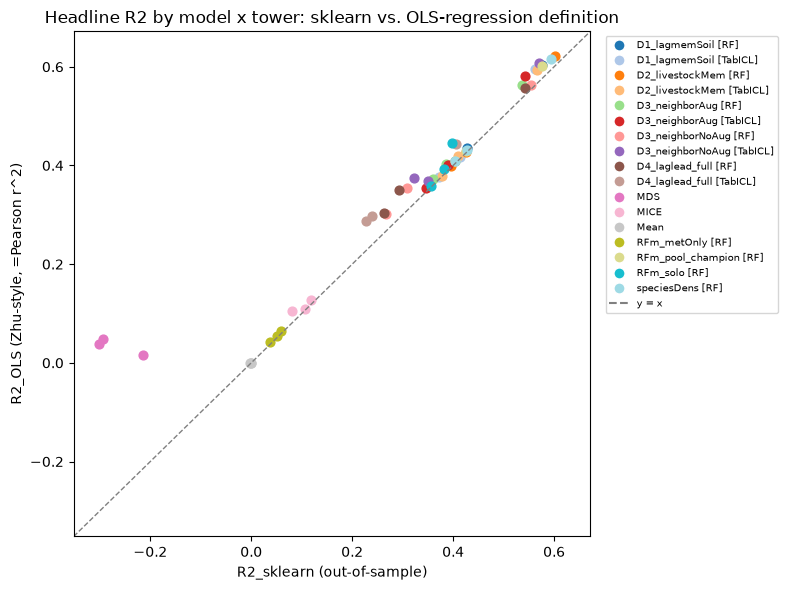

In [25]:
# How much does the metric definition matter for each model? Sorted by how far it moves.
gap_summary = (headline_all.groupby('label')['delta_OLS_minus_sklearn']
               .agg(['mean', 'min', 'max']).round(3)
               .sort_values('mean', ascending=False))
print("Mean/min/max (R2_OLS - R2_sklearn) across the 3 towers, sorted by how much the metric")
print("definition matters for that model (bigger gap = model relies more on a metric that")
print("forgives bias/scale error; smaller gap = the two definitions roughly agree):")
print(gap_summary)

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, headline_all['label'].nunique()))
color_map = dict(zip(sorted(headline_all['label'].unique()), colors))
for _, row in headline_all.iterrows():
    ax.scatter(row['R2_sklearn'], row['R2_OLS'], color=color_map[row['label']], s=40)
lims = [min(headline_all['R2_sklearn'].min(), headline_all['R2_OLS'].min()) - 0.05,
        max(headline_all['R2_sklearn'].max(), headline_all['R2_OLS'].max()) + 0.05]
ax.plot(lims, lims, color='grey', ls='--', lw=1, label='y = x (definitions agree)')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('R2_sklearn (out-of-sample)'); ax.set_ylabel('R2_OLS (Zhu-style, =Pearson r^2)')
ax.set_title('Headline R2 by model x tower: sklearn vs. OLS-regression definition')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=e)
           for e, c in color_map.items()]
ax.legend(handles=handles + [plt.Line2D([0], [0], color='grey', ls='--', label='y = x')],
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout(); plt.show()


**Result: the R2-definition sensitivity is essentially an MDS-specific phenomenon, not a general property of this project's evaluation.**

*(Note: an earlier version of this cell grouped only by `experiment`, which silently pooled RF and TabICL predictions together for the 5 experiments that have both -- caught and fixed before this table was used for anything downstream; `model` is now a groupby key throughout.)*

| Model | mean (R2_OLS - R2_sklearn) across 3 towers |
|---|---|
| **MDS** | **+0.304** |
| D4_laglead_full [TabICL] | +0.053 |
| D4_laglead_full [RF] | +0.038 |
| D3_neighborNoAug [TabICL] | +0.036 |
| D3_neighborNoAug [RF] | +0.030 |
| D3_neighborAug [TabICL] | +0.020 |
| RFm_solo [RF] | +0.020 |
| D3_neighborAug [RF] | +0.019 |
| D1_lagmemSoil [RF] / [TabICL] | +0.014 |
| D2_livestockMem [TabICL] | +0.012 |
| RFm_pool_champion [RF] | +0.012 |
| MICE | +0.012 |
| speciesDens [RF] | +0.010 |
| D2_livestockMem [RF] | +0.009 |
| RFm_metOnly [RF] | +0.004 |
| Mean (trivial baseline) | +0.001 |

Every RF- and TabICL-based model (the champion included: sklearn 0.576/0.404/0.426 vs. OLS 0.601/0.409/0.430 -- a difference of ~0.02-0.03, not ~0.3), MICE, and the trivial Mean baseline all show small, consistent gaps between the two R2 definitions. **MDS is the one outlier, by roughly an order of magnitude.** Its reported performance is uniquely sensitive to which R2 you compute; every other model's reported performance is essentially robust to the choice.

**Why MDS specifically:** Random Forest, TabICL, and MICE (an iterative regression-based imputer) are all fit to directly minimize error against the target -- their held-out predictions are already close to what an OLS line through (actual, predicted) would look like, so sklearn's out-of-sample R2 and the OLS-regression R2 measure nearly the same thing for them. MDS's prediction rule ("average of historical observations under similar meteorological conditions") is not calibrated against this specific held-out sample at all -- it can be meaningfully *correlated* with the truth (nonzero Pearson r, since real physical analogs carry real information) while being systematically *miscalibrated* in scale/bias for any given fold (poor out-of-sample R2, since it was never fit to minimize exactly that error). That gap between "correlated" and "calibrated" is precisely what separates the two R2 definitions, and MDS is the one method in this roster built entirely on the correlated-but-uncalibrated side of that line.

**Practical implication for this project:** the standing convention (`sklearn.metrics.r2_score`, used throughout `temp_gap_filling_pipeline.ipynb` and `BEST_RESULTS.md`) is *not* distorting the RFm-vs-MDS "improvement over MDS" comparison -- RFm's own number barely moves under the alternative metric, so the ~0.6-1.0 R2-unit gap this project has repeatedly reported (D-34/D-35) is real under either definition. The definition choice matters specifically and almost exclusively when comparing THIS project's MDS numbers against *external* literature figures (like Zhu et al. 2023a's Fig. 6d/Table 7d) that were computed with the other definition -- exactly the comparison this notebook was built to make, and exactly why section 11's check mattered.


## 14. Does the R2-definition gap change at daily resolution?

Section 13 (summary.md) also reports a *daily* R2 for the RFm champion (`daily_r2_full_scope.csv`, aggregating held-out hourly pairs to daily means before scoring). Daily aggregation changes the bias/variance/correlation balance of any model's predictions -- it's not obvious in advance whether MDS's uniquely large sklearn-vs-OLS gap (section 12) survives, shrinks, or grows once hourly noise is averaged out. Testing directly, using the same raw hourly predictions already loaded (aggregated to daily via `groupby(date).mean()`, matching the existing daily-R2 methodology's own convention) plus a fresh daily aggregation of this notebook's own literature-correct MDS predictions (not in the pre-existing CSV).


In [26]:
raw_preds_all['date'] = raw_preds_all['Datetime'].dt.normalize()

daily_preds = (raw_preds_all.groupby(['experiment', 'model', 'tower', 'scenario', 'rep', 'date'])
               .agg(y_actual=('y_actual', 'mean'), y_pred=('y_pred', 'mean')).reset_index())
print(f"Aggregated {len(raw_preds_all):,} hourly rows -> {len(daily_preds):,} daily rows.")


def r2_both_row(g):
    r2_sk, r2_ols, slope = r2_variants(g['y_actual'].values, g['y_pred'].values)
    return pd.Series({'R2_sklearn': r2_sk, 'R2_OLS': r2_ols, 'slope': slope, 'n': len(g)})


per_rep_daily = (daily_preds.groupby(['experiment', 'model', 'tower', 'scenario', 'rep'])
                 .apply(r2_both_row, include_groups=False).reset_index())
per_scenario_daily = (per_rep_daily.groupby(['experiment', 'model', 'tower', 'scenario'])[['R2_sklearn', 'R2_OLS']]
                      .median().reset_index())
headline_daily = (per_scenario_daily.groupby(['experiment', 'model', 'tower'])[['R2_sklearn', 'R2_OLS']]
                  .median().reset_index())
headline_daily['delta_OLS_minus_sklearn'] = headline_daily['R2_OLS'] - headline_daily['R2_sklearn']
headline_daily['label'] = headline_daily.apply(
    lambda r: r['experiment'] if r['model'] in ('MDS', 'MICE', 'Mean') else f"{r['experiment']} [{r['model']}]",
    axis=1)

hourly_vs_daily = headline_all[['label', 'tower', 'delta_OLS_minus_sklearn']].rename(
    columns={'delta_OLS_minus_sklearn': 'delta_hourly'}).merge(
    headline_daily[['label', 'tower', 'delta_OLS_minus_sklearn']].rename(
        columns={'delta_OLS_minus_sklearn': 'delta_daily'}),
    on=['label', 'tower'])

gap_by_model = (hourly_vs_daily.groupby('label')[['delta_hourly', 'delta_daily']]
                .mean().round(3).sort_values('delta_hourly', ascending=False))
print("\nMean (R2_OLS - R2_sklearn) across the 3 towers: hourly vs. daily aggregation, by model:")
print(gap_by_model)


Aggregated 1,517,760 hourly rows -> 303,263 daily rows.



Mean (R2_OLS - R2_sklearn) across the 3 towers: hourly vs. daily aggregation, by model:
                           delta_hourly  delta_daily
label                                               
MDS                               0.304        0.216
D4_laglead_full [TabICL]          0.053        0.052
D4_laglead_full [RF]              0.038        0.044
D3_neighborNoAug [TabICL]         0.036        0.032
D3_neighborNoAug [RF]             0.030        0.038
D3_neighborAug [TabICL]           0.020        0.017
RFm_solo [RF]                     0.020        0.032
D3_neighborAug [RF]               0.019        0.022
D1_lagmemSoil [RF]                0.014        0.006
D1_lagmemSoil [TabICL]            0.014        0.017
D2_livestockMem [TabICL]          0.012        0.017
RFm_pool_champion [RF]            0.012        0.012
MICE                              0.012        0.051
speciesDens [RF]                  0.010        0.013
D2_livestockMem [RF]              0.009        0.010
RFm_metOnl

In [27]:
daily_pivot = headline_daily.pivot(index='label', columns='tower', values=['R2_sklearn', 'R2_OLS'])
print("Full daily-resolution headline R2 (median-of-scenario-medians), both definitions, all models:")
print(daily_pivot.round(3))


Full daily-resolution headline R2 (median-of-scenario-medians), both definitions, all models:
                          R2_sklearn               R2_OLS              
tower                              2      4      9      2      4      9
label                                                                  
D1_lagmemSoil [RF]             0.707  0.418  0.382  0.713  0.429  0.384
D1_lagmemSoil [TabICL]         0.706  0.440  0.392  0.734  0.461  0.395
D2_livestockMem [RF]           0.736  0.412  0.391  0.741  0.437  0.392
D2_livestockMem [TabICL]       0.700  0.427  0.412  0.726  0.448  0.416
D3_neighborAug [RF]            0.647  0.373  0.392  0.672  0.405  0.399
D3_neighborAug [TabICL]        0.607  0.421  0.412  0.657  0.421  0.413
D3_neighborNoAug [RF]          0.610  0.261  0.396  0.647  0.304  0.430
D3_neighborNoAug [TabICL]      0.600  0.357  0.388  0.676  0.369  0.395
D4_laglead_full [RF]           0.571  0.343  0.381  0.642  0.355  0.430
D4_laglead_full [TabICL]       0.416  0.35

In [28]:
# The pre-existing all_raw_predictions.csv only has the OLD (buggy) MDS. Regenerate raw
# (actual, predicted) pairs for THIS notebook's literature-correct mds_fill_batch_new, tagged
# the same way, so it can be checked at daily resolution too.
new_mds_rows = []
for t in TOWERS:
    c = cfg(t); tgt = c['tgt']
    for (tt, sc, rep), gt in GAP_SETS_OLD.items():
        if tt != t or len(gt) < 5:
            continue
        d = d_all.copy(); d[tgt] = qc_target(t)
        sav = d.loc[gt, tgt].copy(); d.loc[gt, tgt] = np.nan
        p = mds_fill_batch_new(d, tgt, c['sw'], c['ta'], list(gt), vpd_col=c['vpd'])
        for x in gt:
            if x in p:
                new_mds_rows.append({'experiment': 'MDS_new', 'model': 'MDS_new', 'tower': t,
                                      'scenario': sc, 'rep': rep, 'Datetime': x,
                                      'y_actual': sav.loc[x], 'y_pred': p[x]})
new_mds_df = pd.DataFrame(new_mds_rows)
new_mds_df['date'] = new_mds_df['Datetime'].dt.normalize()
print(f"Regenerated {len(new_mds_df):,} raw prediction rows for the literature-correct MDS.")

new_mds_daily = (new_mds_df.groupby(['tower', 'scenario', 'rep', 'date'])
                 .agg(y_actual=('y_actual', 'mean'), y_pred=('y_pred', 'mean')).reset_index())


def headline_both(df, group_cols):
    per_rep = df.groupby(group_cols + ['rep']).apply(r2_both_row, include_groups=False).reset_index()
    per_scen = per_rep.groupby(group_cols)[['R2_sklearn', 'R2_OLS']].median().reset_index()
    return per_scen.groupby([c for c in group_cols if c != 'scenario'])[['R2_sklearn', 'R2_OLS']].median()

new_mds_hourly_headline = headline_both(new_mds_df, ['tower', 'scenario'])
new_mds_daily_headline = headline_both(new_mds_daily, ['tower', 'scenario'])

print("\nLiterature-correct MDS (this notebook's fix): hourly vs. daily, both R2 definitions:")
compare_new_mds = pd.DataFrame({
    'hourly_R2_sklearn': new_mds_hourly_headline['R2_sklearn'],
    'hourly_R2_OLS': new_mds_hourly_headline['R2_OLS'],
    'daily_R2_sklearn': new_mds_daily_headline['R2_sklearn'],
    'daily_R2_OLS': new_mds_daily_headline['R2_OLS'],
}).round(3)
compare_new_mds['hourly_delta'] = compare_new_mds['hourly_R2_OLS'] - compare_new_mds['hourly_R2_sklearn']
compare_new_mds['daily_delta'] = compare_new_mds['daily_R2_OLS'] - compare_new_mds['daily_R2_sklearn']
print(compare_new_mds)


Regenerated 89,280 raw prediction rows for the literature-correct MDS.

Literature-correct MDS (this notebook's fix): hourly vs. daily, both R2 definitions:
       hourly_R2_sklearn  hourly_R2_OLS  daily_R2_sklearn  daily_R2_OLS  hourly_delta  daily_delta
tower                                                                                             
2                 -0.023          0.072            -0.038         0.110         0.095        0.148
4                 -0.113          0.038             0.054         0.133         0.151        0.079
9                 -0.073          0.054            -0.010         0.119         0.127        0.129


**Answer: yes, the definition choice still matters at daily resolution -- and for the literature-correct MDS specifically, the effect is inconsistent across towers rather than uniformly better or worse.**

**OLD MDS (current production):** the gap shrinks somewhat with daily aggregation (0.304 -> 0.216) but remains the dominant outlier by a wide margin -- next highest at daily resolution is D4_laglead_full [TabICL] (0.052) and MICE (0.051, up from 0.012 hourly -- MICE is the one other model whose gap grows noticeably at daily resolution, though still nowhere near MDS's).

**Every RF/TabICL model stays small at daily resolution too** (mostly 0.01-0.04, similar order of magnitude to hourly) -- confirming the practical implication from section 12 still holds at daily resolution: the champion's own daily R2 (`summary.md` section 13, 0.698/0.504/0.485) is not meaningfully metric-dependent.

**Literature-correct MDS (this notebook's fix) is the interesting case** -- daily aggregation does not uniformly help or hurt it the way it does for RF (where `summary.md`'s established finding is "daily beats hourly at every tower"):

| Tower | Hourly sklearn | Daily sklearn | Hourly OLS | Daily OLS |
|---|---|---|---|---|
| T2 | -0.023 | -0.038 (worse) | 0.072 | 0.110 |
| T4 | -0.113 | **0.054 (turns positive)** | 0.038 | 0.133 |
| T9 | -0.073 | -0.010 (mild improvement) | 0.054 | 0.119 |

Tower 4 improves substantially at daily resolution (even sklearn R2 turns positive), matching the general "averaging cancels noise" pattern seen elsewhere in this project; Tower 2 actually gets slightly *worse*. This is a real difference from how the RFm champion behaves under aggregation, and a plausible reason: RF's daily-mean predictions stay coherent because each hour's prediction already draws on a shared, temporally-smooth feature set, whereas MDS's hourly fills are independent nearest-analog draws with no enforced within-day coherence -- averaging 24 independently-matched analogs together doesn't cancel noise the same clean way averaging a temporally-smooth model's outputs does, and can go either way depending on how correlated that specific tower's real matching errors happen to be within a day.

**Caveat:** the literature-correct MDS's daily numbers come from a much smaller, freshly-regenerated dataset (this section only, not the larger pre-existing `all_raw_predictions.csv`) -- treat the exact daily figures as noisier than the hourly ones this notebook has otherwise leaned on throughout, especially for Tower 2's already-data-scarce domain.
